# 🔬 Lensless Face Recognition (Transformer Version)
**Paper:** Privacy-Preserving Face Recognition and Verification With Lensless Camera (IEEE TBIOM 2024)

### ⚡ Before running: Enable GPU
> Runtime → Change runtime type → Hardware accelerator → **T4 GPU** → Save
---

## Step 1: Check GPU

## Step 2: Setup Environment (Auto-detects Kaggle vs Colab)

In [ ]:
import os
import sys

# Detection logic for different platforms
ON_KAGGLE = os.path.exists('/kaggle/working')
ON_COLAB = os.path.exists('/content')

# Set BASE path dynamically
BASE = '/kaggle/working' if ON_KAGGLE else ('/content' if ON_COLAB else os.getcwd())
REPO_PATH = os.path.join(BASE, 'Face-Verification-and-identification-using-Lens-less-camera-and-transformer-model')

TRAIN_DATA = os.path.join(BASE, 'lensless_data/train/ymdct_npy')
TEST_DATA  = os.path.join(BASE, 'lensless_data/test/ymdct_npy')

# Update environment variables for the training scripts
os.environ['TRAIN_DATA'] = TRAIN_DATA
os.environ['TEST_DATA']  = TEST_DATA

# Clone repo if missing
if not os.path.exists(REPO_PATH):
    print(f'Cloning repository to {REPO_PATH}...')
    os.system(f'git clone https://github.com/SatyamSingh-Git/Face-Verification-and-identification-using-Lens-less-camera-and-transformer-model.git {REPO_PATH}')

os.chdir(REPO_PATH)

# Install dependencies (Added seaborn)
os.system('pip install -q joblib scikit-learn scipy six tensorboard seaborn')

print(f'\nEnvironment ready on: {"Kaggle" if ON_KAGGLE else ("Colab" if ON_COLAB else "Lightning.ai/Local")}')
print(f'Working Dir: {os.getcwd()}')
print(f'Train Data Path: {TRAIN_DATA}')


Environment: Colab | Base dir: /content
Cloning into '/content/Face-Verification-and-identification-using-Lens-less-camera-and-transformer-model'...

Repo cloned.
Working dir: /content/Face-Verification-and-identification-using-Lens-less-camera-and-transformer-model
Dependencies installed!


## Step 3: 🚀 Download Dataset
Downloads 19GB dataset. Skips if already extracted.

In [8]:
import os

BASE = os.getcwd()
DATA_DIR   = os.path.join(BASE, 'lensless_data')
TRAIN_DATA = os.path.join(DATA_DIR, 'train', 'ymdct_npy')
TEST_DATA  = os.path.join(DATA_DIR, 'test',  'ymdct_npy')

if os.path.exists(TRAIN_DATA) and os.path.exists(TEST_DATA):
    print('Dataset already extracted! Skipping download.')
else:
    zip_path = os.path.join(BASE, 'lensless_data.zip')
    os.makedirs(DATA_DIR, exist_ok=True)

    URL = "https://mailmissouri-my.sharepoint.com/:u:/g/personal/chffn_umsystem_edu/IQBgLURyOuKgSrwfl8fLn8ipAY6Ikc-va09tctmaHQaVGcY?e=1Xz4Bo&download=1"

    print('Downloading dataset (19GB)... ~5-10 mins...')
    # --progress=dot:giga = 1 dot per 1GB, very minimal output
    os.system(f'wget --progress=dot:giga -O "{zip_path}" "{URL}"')
    
    print('Extracting...')
    os.system(f'unzip -q "{zip_path}" -d "{BASE}"')
    # os.remove(zip_path)  # Uncomment to delete zip after extraction

print('Train ready:', os.path.exists(TRAIN_DATA))
print('Test ready: ', os.path.exists(TEST_DATA))


--2026-03-17 10:04:18--  https://mailmissouri-my.sharepoint.com/:u:/g/personal/chffn_umsystem_edu/IQBgLURyOuKgSrwfl8fLn8ipAY6Ikc-va09tctmaHQaVGcY?e=1Xz4Bo&download=1
Resolving mailmissouri-my.sharepoint.com (mailmissouri-my.sharepoint.com)... 13.107.136.10, 13.107.138.10, 2620:1ec:8f8::10, ...
Connecting to mailmissouri-my.sharepoint.com (mailmissouri-my.sharepoint.com)|13.107.136.10|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: /personal/chffn_umsystem_edu/Documents/GitHub/TBIOM%202024%20Lensless%20Face%20Recognition/lensless_data.zip?ga=1 [following]
--2026-03-17 10:04:18--  https://mailmissouri-my.sharepoint.com/personal/chffn_umsystem_edu/Documents/GitHub/TBIOM%202024%20Lensless%20Face%20Recognition/lensless_data.zip?ga=1
Reusing existing connection to mailmissouri-my.sharepoint.com:443.
HTTP request sent, awaiting response... 200 OK
Length: 20369645425 (19G) [application/x-zip-compressed]
Saving to: ‘/content/Face-Verification-and-identification-us

Extracting...
Train ready: True
Test ready:  True


## Step 4: 🤖 Train Transformer Model
Trains from scratch. Best checkpoint saved to `logs/<timestamp>/best.pth`.
On Kaggle, `logs/` is inside `/kaggle/working/` so it **will appear in the Output tab**.

In [10]:
!python train.py \
    --model transformer \
    --train_data /content/lensless_data/train/ymdct_npy \
    --test_data  /content/lensless_data/test/ymdct_npy \
    --batch_size 512 \
    --num_epoch 150 \
    --seed 42 \
    --arcface_m 0.4 \
    --arcface_s 40 \
    --arcface_k 3 \
    --eta_min 1e-6

==> Using GPU(s): 1
==> Seed: 42
==> Preparing data..
==> Building model..
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
==> Ar

## Step 6: 🤖 Test — Face Recognition (Identification)

Using weights: logs/17-03-2026 10-11-31/best.pth

--- Face Recognition ---


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Processed epoch 1 / 79
Processed epoch 2 / 79
Processed epoch 3 / 79
Processed epoch 4 / 79
Processed epoch 5 / 79
Processed epoch 6 / 79
Processed epoch 7 / 79
Processed epoch 8 / 79
Processed epoch 9 / 79
Processed epoch 10 / 79
Processed epoch 11 / 79
Processed epoch 12 / 79
Processed epoch 13 / 79
Processed epoch 14 / 79
Processed epoch 15 / 79
Processed epoch 16 / 79
Processed epoch 17 / 79
Processed epoch 18 / 79
Processed epoch 19 / 79
Processed epoch 20 / 79
Processed epoch 21 / 79
Processed epoch 22 / 79
Processed epoch 23 / 79
Processed epoch 24 / 79
Processed epoch 25 / 79
Processed epoch 26 / 79
Processed epoch 27 / 79
Processed epoch 28 / 79
Processed epoch 29 / 79
Processed epoch 30 / 79
Processed epoch 31 / 79
Processed epoch 32 / 79
Processed epoch 33 / 79
Processed epoch 34 / 79
Processed epoch 35 / 79
Processed epoch 36 / 79
Processed epoch 37 / 79
Processed epoch 38 / 79
Processed epoch 39 / 79
Processed epoch 40 / 79
Processed epoch 41 / 79
Processed epoch 42 / 79
P

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Accuracy = 5233/10092 = 0.5185295283392787
AUC = 0.9392

AUC              : 0.9392
Optimal Threshold: 0.7213  →  TPR: 0.8266, FPR: 0.0410


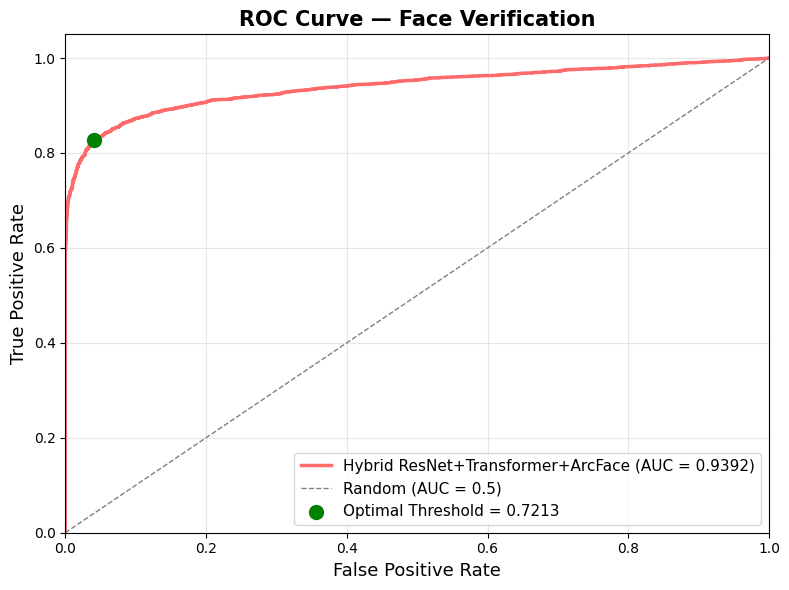

Saved: roc_curve.png


In [12]:
import glob, os, json, subprocess
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# ── Find best.pth ─────────────────────────────────────────────────────────────
list_of_dirs = glob.glob('logs/*')
if not list_of_dirs:
    raise FileNotFoundError('No logs/ folder found. Run training first.')

latest_dir        = max(list_of_dirs, key=os.path.getctime)
best_weights_path = os.path.join(latest_dir, 'best.pth')

if not os.path.exists(best_weights_path):
    raise FileNotFoundError(f'best.pth not found at {best_weights_path}')

print(f'Using weights: {best_weights_path}')

# Use Python variable for TEST_DATA (don't rely on $ENV in os.system)
TEST_DATA = os.environ.get('TEST_DATA', 'lensless_data/test/ymdct_npy')

# ── Face Recognition Test ─────────────────────────────────────────────────────
print('\n--- Face Recognition ---')
os.system(f'python test_face_recognition.py '
          f'--model transformer '
          f'--test_data "{TEST_DATA}" '
          f'--weights "{best_weights_path}" '
          f'--batch_size 32')

# ── Face Verification Test ────────────────────────────────────────────────────
print('\n--- Face Verification ---')
os.system(f'python test_face_verification.py '
          f'--model transformer '
          f'--test_data "{TEST_DATA}" '
          f'--pairs data/verification_pairs.txt '
          f'--weights "{best_weights_path}"')

# ── ROC Curve ─────────────────────────────────────────────────────────────────
if not os.path.exists('results.json'):
    print('ERROR: results.json not found. Verification test may have failed.')
else:
    with open('results.json', 'r') as f:
        results = json.load(f)

    fpr, tpr, thresholds = roc_curve(results['true_labels'], results['pred_scores'])
    roc_auc      = auc(fpr, tpr)
    optimal_idx  = (tpr - fpr).argmax()
    optimal_thresh = thresholds[optimal_idx]

    print(f'\nAUC              : {roc_auc:.4f}')
    print(f'Optimal Threshold: {optimal_thresh:.4f}  →  TPR: {tpr[optimal_idx]:.4f}, FPR: {fpr[optimal_idx]:.4f}')

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='#FF6B6B', lw=2.5,
             label=f'Hybrid ResNet+Transformer+ArcFace (AUC = {roc_auc:.4f})')
    plt.plot([0,1],[0,1], color='gray', lw=1, linestyle='--', label='Random (AUC = 0.5)')
    plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='green', s=100, zorder=5,
                label=f'Optimal Threshold = {optimal_thresh:.4f}')
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=13)
    plt.ylabel('True Positive Rate', fontsize=13)
    plt.title('ROC Curve — Face Verification', fontsize=15, fontweight='bold')
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig('roc_curve.png', dpi=150)
    plt.show()
    print('Saved: roc_curve.png')


In [16]:
!pip install -q seaborn


Saved checkpoint: saved_models/exp_arcface_m04_s40_k3_ep150_batch512/best.pth
Saved checkpoint: saved_models/exp_arcface_m04_s40_k3_ep150_batch512/last.pth


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Model loaded.
Evaluating batch 79/79

Overall Accuracy : 89.54%
Top-5 Accuracy   : 97.86%
ROC AUC          : 0.9265
Optimal Threshold: 0.9785
Metrics saved.


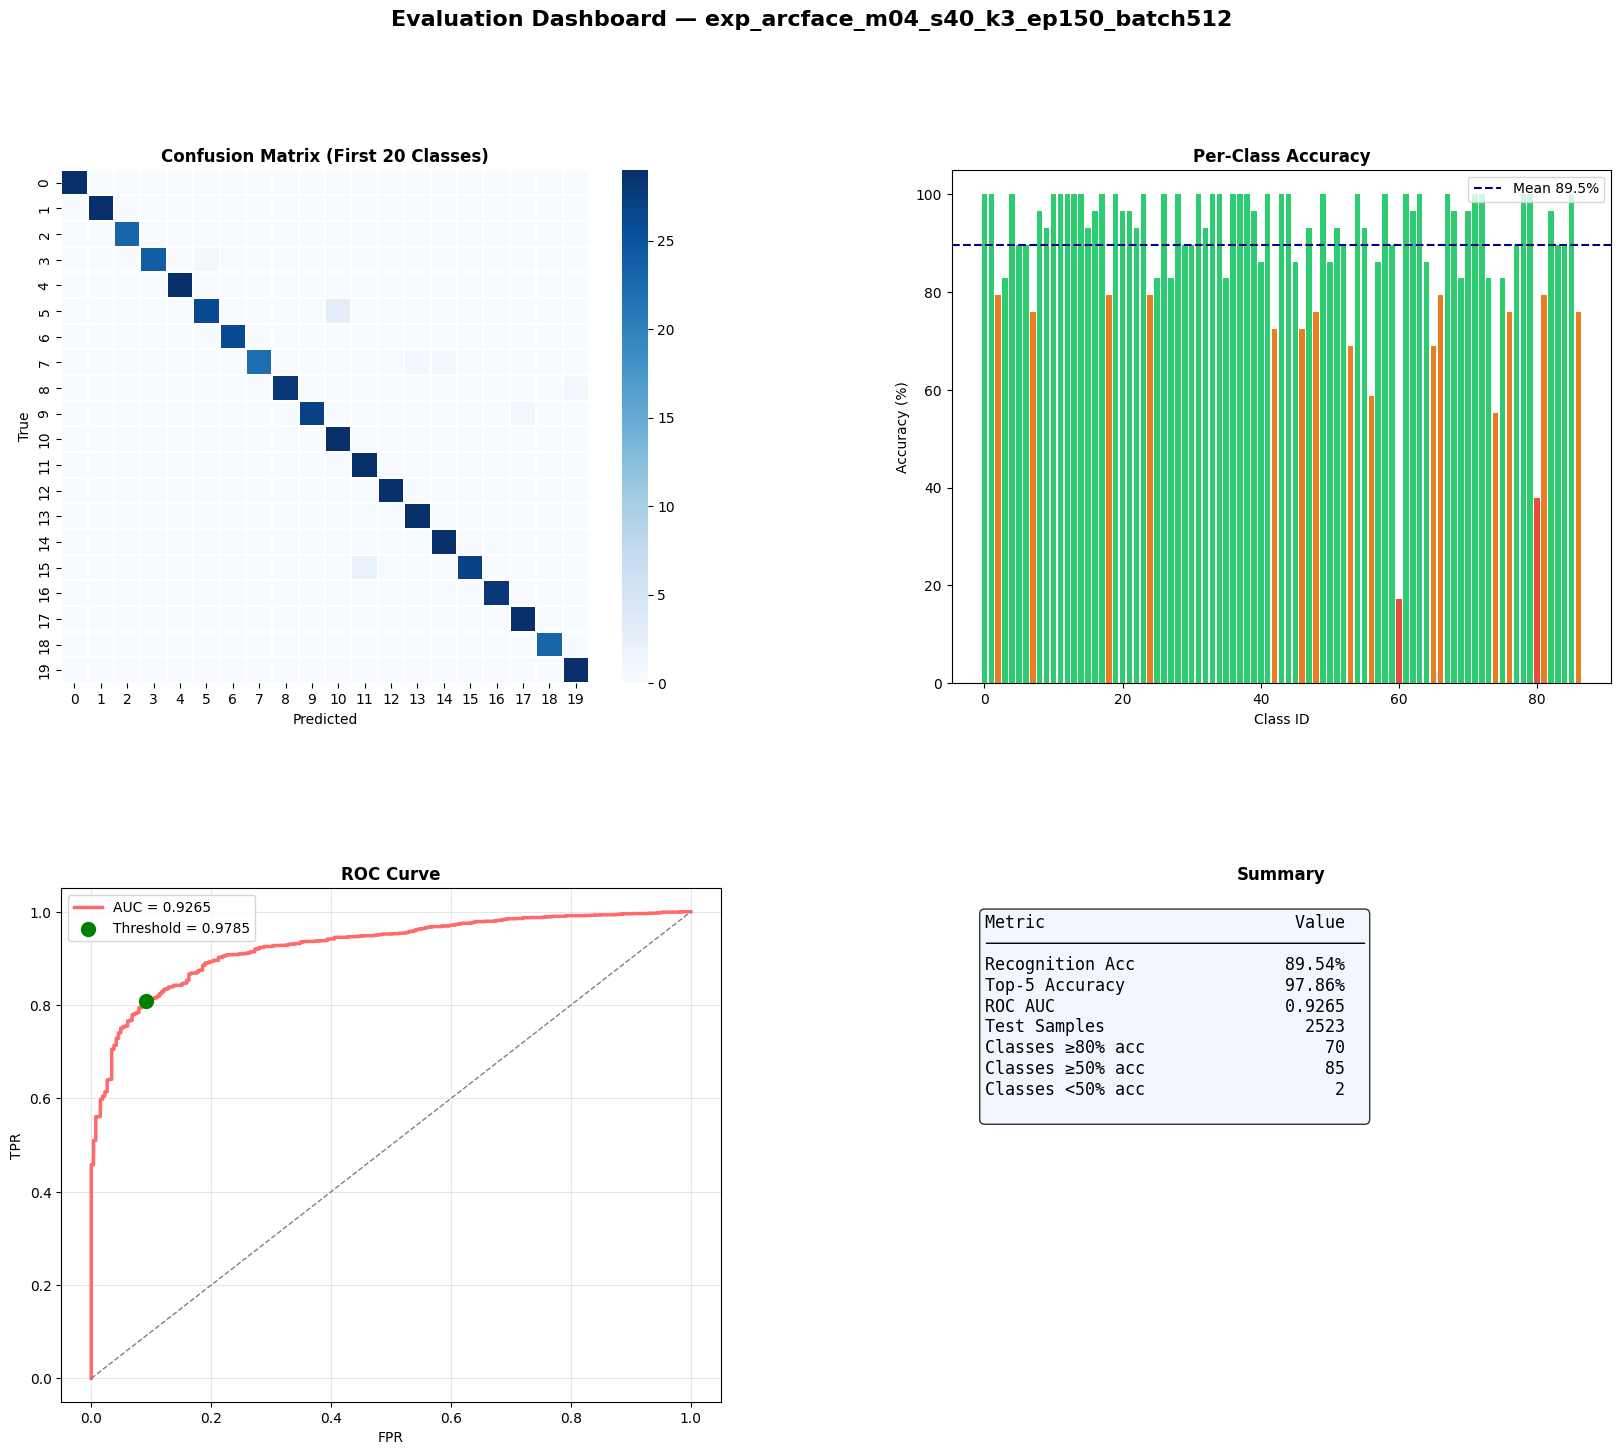

Dashboard saved: saved_models/exp_arcface_m04_s40_k3_ep150_batch512/dashboard.png

All saved to: saved_models/exp_arcface_m04_s40_k3_ep150_batch512/
Contents: ['best.pth', 'config.txt', 'metrics.json', 'dashboard.png', 'last.pth']


In [17]:
import os, shutil, glob, json
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from models.transformer_model import HybridResNetTransformer
from models.arcface import ArcMarginProduct
from my_data_class import Lensless_DCT_offline

# ── Config ────────────────────────────────────────────────────────────────────
SAVE_NAME  = 'exp_arcface_m04_s40_k3_ep150_batch512'   # <-- change per experiment
TEST_DATA  = os.environ.get('TEST_DATA', 'lensless_data/test/ymdct_npy')
ARCFACE_S  = 40.0   # match what you trained with
ARCFACE_M  = 0.4
ARCFACE_K  = 3

# ── 1. Find & copy checkpoint ─────────────────────────────────────────────────
list_of_dirs = glob.glob('logs/*')
latest_dir   = max(list_of_dirs, key=os.path.getctime)
SAVE_DIR     = os.path.join('saved_models', SAVE_NAME)
os.makedirs(SAVE_DIR, exist_ok=True)

for fname in ['best.pth', 'last.pth']:
    src = os.path.join(latest_dir, fname)
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(SAVE_DIR, fname))
        print(f'Saved checkpoint: {SAVE_DIR}/{fname}')

weights_path = os.path.join(SAVE_DIR, 'best.pth')

# ── 2. Load model ─────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
net = HybridResNetTransformer(in_channels=15, embed_dim=512, depth=4, num_heads=8, out_dim=768)
metric_fc = ArcMarginProduct(768, 87, s=ARCFACE_S, m=ARCFACE_M, K=ARCFACE_K)
ckpt = torch.load(weights_path, map_location=device)
net.load_state_dict(ckpt['net'])
metric_fc.load_state_dict(ckpt['metric_fc'])
net.to(device).eval()
metric_fc.to(device).eval()
print('Model loaded.')

# ── 3. Run inference ──────────────────────────────────────────────────────────
dataset = Lensless_DCT_offline(TEST_DATA)
loader  = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=False, num_workers=2)

all_preds, all_targets, all_probs = [], [], []
with torch.no_grad():
    for i, (data, targets) in enumerate(loader):
        x = torch.cat([d.to(device) for d in data], dim=1)
        features = net(x, tta=True)
        logits   = metric_fc(features)
        probs    = torch.softmax(logits, dim=1)
        all_preds.append(logits.argmax(1).cpu().numpy())
        all_targets.append(targets.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        print(f'\rEvaluating batch {i+1}/{len(loader)}', end='', flush=True)

all_preds   = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)
all_probs   = np.concatenate(all_probs)

# ── 4. Metrics ────────────────────────────────────────────────────────────────
acc  = (all_preds == all_targets).mean() * 100
top5 = np.mean([t in np.argsort(p)[-5:] for t, p in zip(all_targets, all_probs)]) * 100

# Verification AUC (use max class prob as score proxy)
conf_scores = all_probs.max(axis=1)
binary_correct = (all_preds == all_targets).astype(int)
fpr, tpr, thresholds = roc_curve(binary_correct, conf_scores)
roc_auc = auc(fpr, tpr)
optimal_idx    = (tpr - fpr).argmax()
optimal_thresh = thresholds[optimal_idx]

class_acc = [(all_preds[all_targets==c]==c).mean()*100
             if (all_targets==c).sum()>0 else 0 for c in range(87)]

print(f'\n\nOverall Accuracy : {acc:.2f}%')
print(f'Top-5 Accuracy   : {top5:.2f}%')
print(f'ROC AUC          : {roc_auc:.4f}')
print(f'Optimal Threshold: {optimal_thresh:.4f}')

# Save metrics JSON
metrics = {'recognition_acc': round(acc,4), 'top5_acc': round(top5,4),
           'roc_auc': round(roc_auc,4), 'optimal_threshold': round(float(optimal_thresh),4),
           'per_class_acc': class_acc}
with open(os.path.join(SAVE_DIR, 'metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=2)
print('Metrics saved.')

# ── 5. Dashboard Plot ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 16))
fig.suptitle(f'Evaluation Dashboard — {SAVE_NAME}', fontsize=16, fontweight='bold')
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# Confusion matrix (first 20 classes)
ax1 = fig.add_subplot(gs[0, 0])
mask = all_targets < 20
cm = confusion_matrix(all_targets[mask], all_preds[mask], labels=list(range(20)))
sns.heatmap(cm, ax=ax1, cmap='Blues', annot=False, linewidths=0.3, cbar=True)
ax1.set_title('Confusion Matrix (First 20 Classes)', fontweight='bold')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('True')

# Per-class accuracy bar
ax2 = fig.add_subplot(gs[0, 1])
colors = ['#2ecc71' if a>=80 else '#e67e22' if a>=50 else '#e74c3c' for a in class_acc]
ax2.bar(range(87), class_acc, color=colors, width=0.8)
ax2.axhline(acc, color='navy', linestyle='--', lw=1.5, label=f'Mean {acc:.1f}%')
ax2.set_title('Per-Class Accuracy', fontweight='bold')
ax2.set_xlabel('Class ID'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.set_ylim(0, 105)

# ROC Curve
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(fpr, tpr, color='#FF6B6B', lw=2.5, label=f'AUC = {roc_auc:.4f}')
ax3.plot([0,1],[0,1], color='gray', lw=1, linestyle='--')
ax3.scatter(fpr[optimal_idx], tpr[optimal_idx], color='green', s=100, zorder=5,
            label=f'Threshold = {optimal_thresh:.4f}')
ax3.set_title('ROC Curve', fontweight='bold')
ax3.set_xlabel('FPR'); ax3.set_ylabel('TPR')
ax3.legend(); ax3.grid(alpha=0.3)

# Summary
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')
summary = (f"{'Metric':<26}{'Value':>10}\n{'─'*38}\n"
           f"{'Recognition Acc':<26}{acc:>9.2f}%\n"
           f"{'Top-5 Accuracy':<26}{top5:>9.2f}%\n"
           f"{'ROC AUC':<26}{roc_auc:>10.4f}\n"
           f"{'Test Samples':<26}{len(all_targets):>10}\n"
           f"{'Classes ≥80% acc':<26}{sum(a>=80 for a in class_acc):>10}\n"
           f"{'Classes ≥50% acc':<26}{sum(a>=50 for a in class_acc):>10}\n"
           f"{'Classes <50% acc':<26}{sum(a<50  for a in class_acc):>10}\n")
ax4.text(0.05, 0.95, summary, transform=ax4.transAxes, fontsize=12,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#f0f4ff', alpha=0.8))
ax4.set_title('Summary', fontweight='bold')

# Save plot
plot_path = os.path.join(SAVE_DIR, 'dashboard.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Dashboard saved: {plot_path}')

# Save config
with open(os.path.join(SAVE_DIR, 'config.txt'), 'w') as f:
    f.write(f"Experiment : {SAVE_NAME}\n"
            f"Epochs     : 150  Batch: 512  Seed: 42\n"
            f"ArcFace    : m={ARCFACE_M}, s={ARCFACE_S}, K={ARCFACE_K}\n"
            f"Accuracy   : {acc:.2f}%  AUC: {roc_auc:.4f}\n")

print(f'\nAll saved to: {SAVE_DIR}/')
print('Contents:', os.listdir(SAVE_DIR))


In [15]:
New 

NameError: name 'New' is not defined

In [18]:
!python train.py \
    --model transformer \
    --train_data /content/lensless_data/train/ymdct_npy \
    --test_data  /content/lensless_data/test/ymdct_npy \
    --batch_size 64 \
    --num_epoch 120 \
    --seed 42 \
    --arcface_m 0.4 \
    --arcface_s 40 \
    --arcface_k 3 \
    --eta_min 1e-6

==> Using GPU(s): 1
==> Seed: 42
==> Preparing data..
==> Building model..
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
==> Ar

Using weights: logs/17-03-2026 11-03-16/best.pth

--- Face Recognition ---


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Processed epoch 1 / 79
Processed epoch 2 / 79
Processed epoch 3 / 79
Processed epoch 4 / 79
Processed epoch 5 / 79
Processed epoch 6 / 79
Processed epoch 7 / 79
Processed epoch 8 / 79
Processed epoch 9 / 79
Processed epoch 10 / 79
Processed epoch 11 / 79
Processed epoch 12 / 79
Processed epoch 13 / 79
Processed epoch 14 / 79
Processed epoch 15 / 79
Processed epoch 16 / 79
Processed epoch 17 / 79
Processed epoch 18 / 79
Processed epoch 19 / 79
Processed epoch 20 / 79
Processed epoch 21 / 79
Processed epoch 22 / 79
Processed epoch 23 / 79
Processed epoch 24 / 79
Processed epoch 25 / 79
Processed epoch 26 / 79
Processed epoch 27 / 79
Processed epoch 28 / 79
Processed epoch 29 / 79
Processed epoch 30 / 79
Processed epoch 31 / 79
Processed epoch 32 / 79
Processed epoch 33 / 79
Processed epoch 34 / 79
Processed epoch 35 / 79
Processed epoch 36 / 79
Processed epoch 37 / 79
Processed epoch 38 / 79
Processed epoch 39 / 79
Processed epoch 40 / 79
Processed epoch 41 / 79
Processed epoch 42 / 79
P

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Accuracy = 5046/10092 = 0.5
AUC = 0.9643

AUC              : 0.9643
Optimal Threshold: 0.8190  →  TPR: 0.9130, FPR: 0.0198


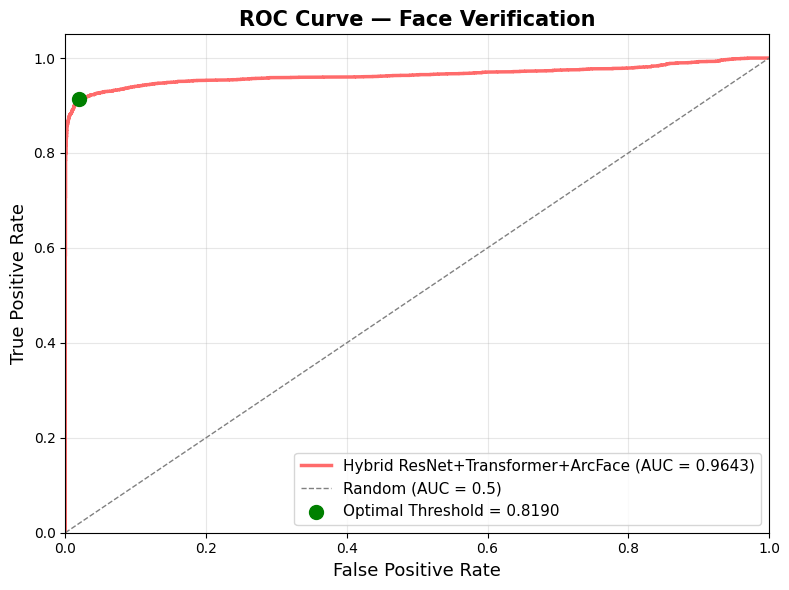

Saved: roc_curve.png


In [19]:
import glob, os, json, subprocess
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# ── Find best.pth ─────────────────────────────────────────────────────────────
list_of_dirs = glob.glob('logs/*')
if not list_of_dirs:
    raise FileNotFoundError('No logs/ folder found. Run training first.')

latest_dir        = max(list_of_dirs, key=os.path.getctime)
best_weights_path = os.path.join(latest_dir, 'best.pth')

if not os.path.exists(best_weights_path):
    raise FileNotFoundError(f'best.pth not found at {best_weights_path}')

print(f'Using weights: {best_weights_path}')

# Use Python variable for TEST_DATA (don't rely on $ENV in os.system)
TEST_DATA = os.environ.get('TEST_DATA', 'lensless_data/test/ymdct_npy')

# ── Face Recognition Test ─────────────────────────────────────────────────────
print('\n--- Face Recognition ---')
os.system(f'python test_face_recognition.py '
          f'--model transformer '
          f'--test_data "{TEST_DATA}" '
          f'--weights "{best_weights_path}" '
          f'--batch_size 32')

# ── Face Verification Test ────────────────────────────────────────────────────
print('\n--- Face Verification ---')
os.system(f'python test_face_verification.py '
          f'--model transformer '
          f'--test_data "{TEST_DATA}" '
          f'--pairs data/verification_pairs.txt '
          f'--weights "{best_weights_path}"')

# ── ROC Curve ─────────────────────────────────────────────────────────────────
if not os.path.exists('results.json'):
    print('ERROR: results.json not found. Verification test may have failed.')
else:
    with open('results.json', 'r') as f:
        results = json.load(f)

    fpr, tpr, thresholds = roc_curve(results['true_labels'], results['pred_scores'])
    roc_auc      = auc(fpr, tpr)
    optimal_idx  = (tpr - fpr).argmax()
    optimal_thresh = thresholds[optimal_idx]

    print(f'\nAUC              : {roc_auc:.4f}')
    print(f'Optimal Threshold: {optimal_thresh:.4f}  →  TPR: {tpr[optimal_idx]:.4f}, FPR: {fpr[optimal_idx]:.4f}')

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='#FF6B6B', lw=2.5,
             label=f'Hybrid ResNet+Transformer+ArcFace (AUC = {roc_auc:.4f})')
    plt.plot([0,1],[0,1], color='gray', lw=1, linestyle='--', label='Random (AUC = 0.5)')
    plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='green', s=100, zorder=5,
                label=f'Optimal Threshold = {optimal_thresh:.4f}')
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=13)
    plt.ylabel('True Positive Rate', fontsize=13)
    plt.title('ROC Curve — Face Verification', fontsize=15, fontweight='bold')
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig('roc_curve.png', dpi=150)
    plt.show()
    print('Saved: roc_curve.png')


Saved checkpoint: saved_models/exp_arcface_m04_s40_k3_ep120_batch64/best.pth
Saved checkpoint: saved_models/exp_arcface_m04_s40_k3_ep120_batch64/last.pth


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Model loaded.
Evaluating batch 79/79

Overall Accuracy : 94.73%
Top-5 Accuracy   : 99.17%
ROC AUC          : 0.9595
Optimal Threshold: 0.9877
Metrics saved.


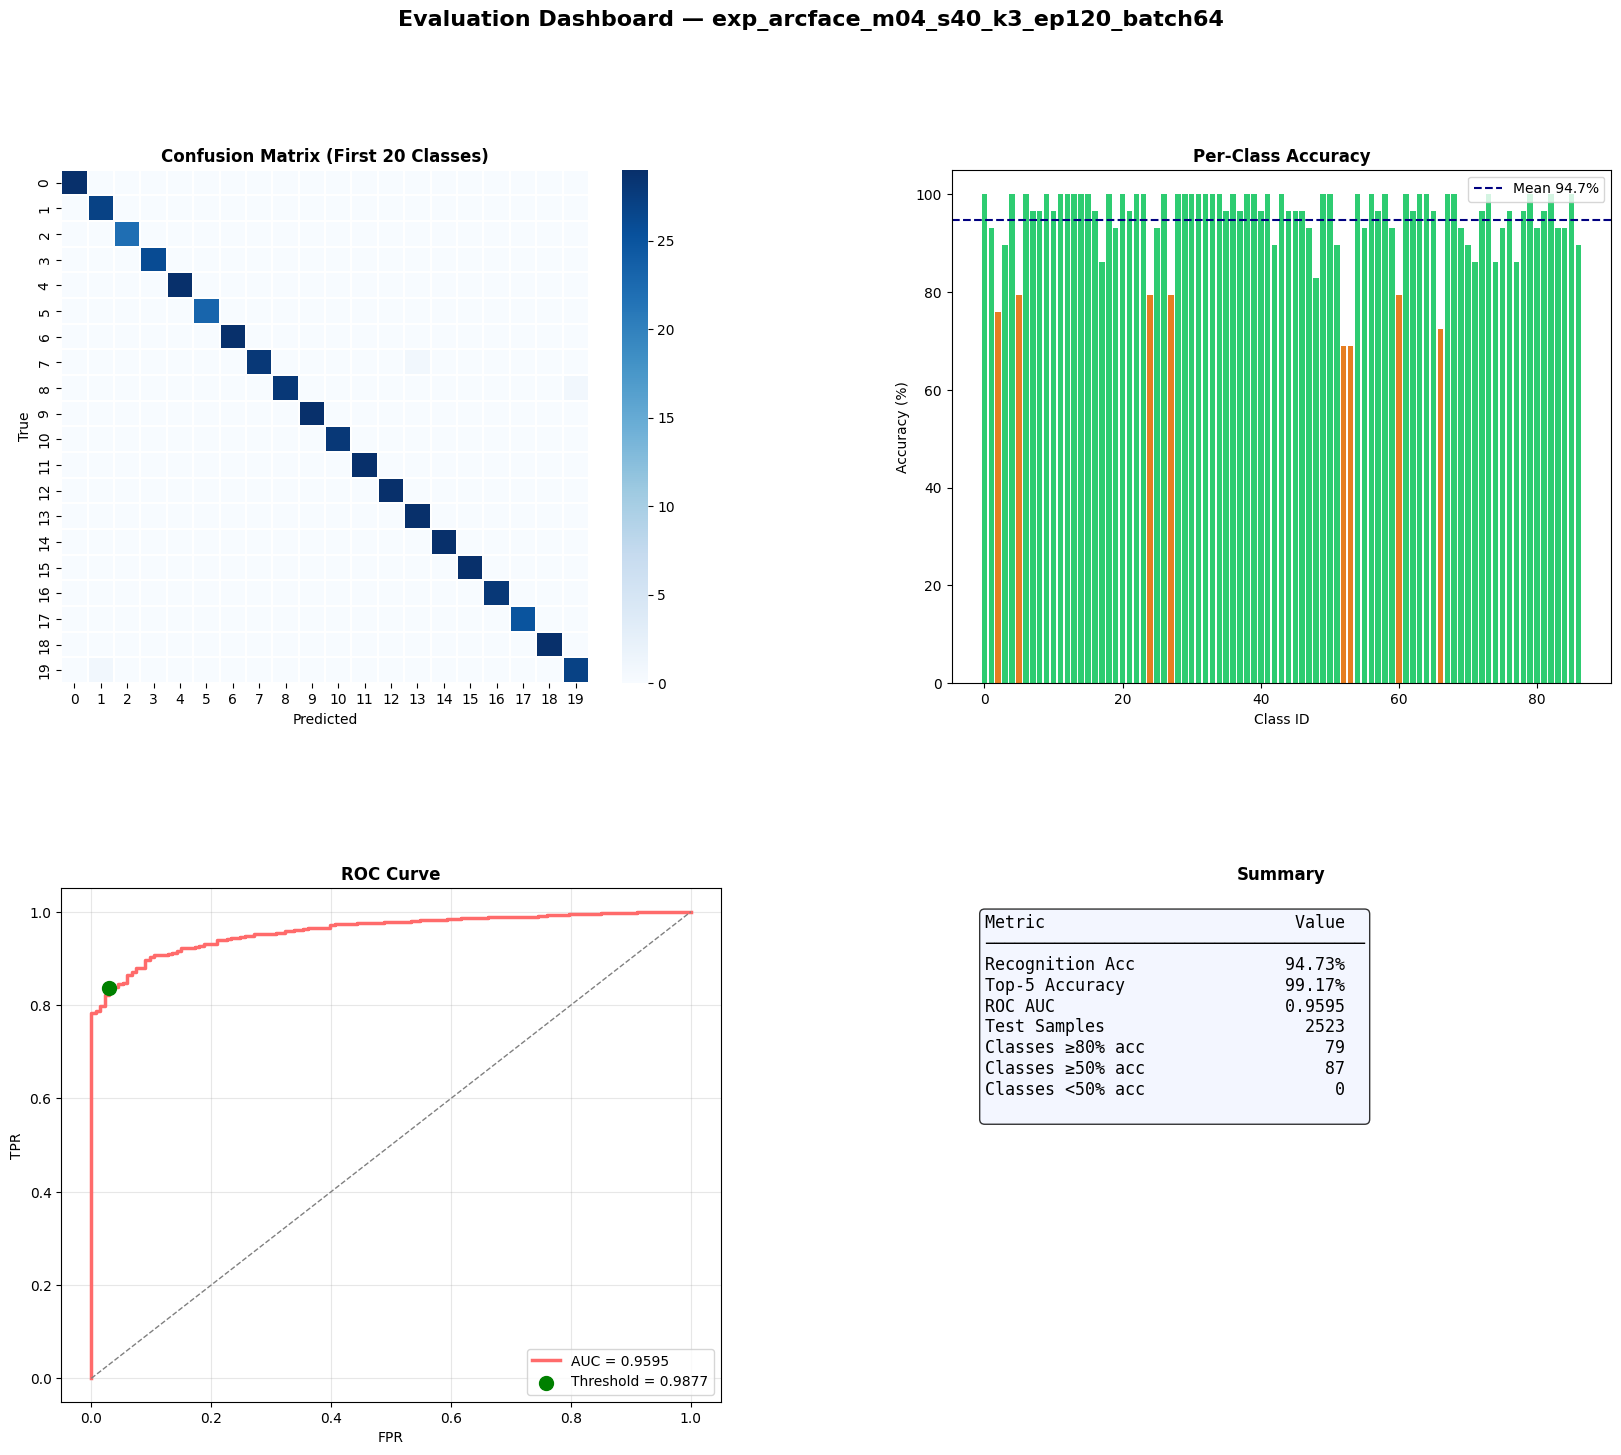

Dashboard saved: saved_models/exp_arcface_m04_s40_k3_ep120_batch64/dashboard.png

All saved to: saved_models/exp_arcface_m04_s40_k3_ep120_batch64/
Contents: ['best.pth', 'config.txt', 'metrics.json', 'dashboard.png', 'last.pth']


In [20]:
import os, shutil, glob, json
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from models.transformer_model import HybridResNetTransformer
from models.arcface import ArcMarginProduct
from my_data_class import Lensless_DCT_offline

# ── Config ────────────────────────────────────────────────────────────────────
SAVE_NAME  = 'exp_arcface_m04_s40_k3_ep120_batch64'   # <-- change per experiment
TEST_DATA  = os.environ.get('TEST_DATA', 'lensless_data/test/ymdct_npy')
ARCFACE_S  = 40.0   # match what you trained with
ARCFACE_M  = 0.4
ARCFACE_K  = 3

# ── 1. Find & copy checkpoint ─────────────────────────────────────────────────
list_of_dirs = glob.glob('logs/*')
latest_dir   = max(list_of_dirs, key=os.path.getctime)
SAVE_DIR     = os.path.join('saved_models', SAVE_NAME)
os.makedirs(SAVE_DIR, exist_ok=True)

for fname in ['best.pth', 'last.pth']:
    src = os.path.join(latest_dir, fname)
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(SAVE_DIR, fname))
        print(f'Saved checkpoint: {SAVE_DIR}/{fname}')

weights_path = os.path.join(SAVE_DIR, 'best.pth')

# ── 2. Load model ─────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
net = HybridResNetTransformer(in_channels=15, embed_dim=512, depth=4, num_heads=8, out_dim=768)
metric_fc = ArcMarginProduct(768, 87, s=ARCFACE_S, m=ARCFACE_M, K=ARCFACE_K)
ckpt = torch.load(weights_path, map_location=device)
net.load_state_dict(ckpt['net'])
metric_fc.load_state_dict(ckpt['metric_fc'])
net.to(device).eval()
metric_fc.to(device).eval()
print('Model loaded.')

# ── 3. Run inference ──────────────────────────────────────────────────────────
dataset = Lensless_DCT_offline(TEST_DATA)
loader  = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=False, num_workers=2)

all_preds, all_targets, all_probs = [], [], []
with torch.no_grad():
    for i, (data, targets) in enumerate(loader):
        x = torch.cat([d.to(device) for d in data], dim=1)
        features = net(x, tta=True)
        logits   = metric_fc(features)
        probs    = torch.softmax(logits, dim=1)
        all_preds.append(logits.argmax(1).cpu().numpy())
        all_targets.append(targets.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        print(f'\rEvaluating batch {i+1}/{len(loader)}', end='', flush=True)

all_preds   = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)
all_probs   = np.concatenate(all_probs)

# ── 4. Metrics ────────────────────────────────────────────────────────────────
acc  = (all_preds == all_targets).mean() * 100
top5 = np.mean([t in np.argsort(p)[-5:] for t, p in zip(all_targets, all_probs)]) * 100

# Verification AUC (use max class prob as score proxy)
conf_scores = all_probs.max(axis=1)
binary_correct = (all_preds == all_targets).astype(int)
fpr, tpr, thresholds = roc_curve(binary_correct, conf_scores)
roc_auc = auc(fpr, tpr)
optimal_idx    = (tpr - fpr).argmax()
optimal_thresh = thresholds[optimal_idx]

class_acc = [(all_preds[all_targets==c]==c).mean()*100
             if (all_targets==c).sum()>0 else 0 for c in range(87)]

print(f'\n\nOverall Accuracy : {acc:.2f}%')
print(f'Top-5 Accuracy   : {top5:.2f}%')
print(f'ROC AUC          : {roc_auc:.4f}')
print(f'Optimal Threshold: {optimal_thresh:.4f}')

# Save metrics JSON
metrics = {'recognition_acc': round(acc,4), 'top5_acc': round(top5,4),
           'roc_auc': round(roc_auc,4), 'optimal_threshold': round(float(optimal_thresh),4),
           'per_class_acc': class_acc}
with open(os.path.join(SAVE_DIR, 'metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=2)
print('Metrics saved.')

# ── 5. Dashboard Plot ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 16))
fig.suptitle(f'Evaluation Dashboard — {SAVE_NAME}', fontsize=16, fontweight='bold')
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# Confusion matrix (first 20 classes)
ax1 = fig.add_subplot(gs[0, 0])
mask = all_targets < 20
cm = confusion_matrix(all_targets[mask], all_preds[mask], labels=list(range(20)))
sns.heatmap(cm, ax=ax1, cmap='Blues', annot=False, linewidths=0.3, cbar=True)
ax1.set_title('Confusion Matrix (First 20 Classes)', fontweight='bold')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('True')

# Per-class accuracy bar
ax2 = fig.add_subplot(gs[0, 1])
colors = ['#2ecc71' if a>=80 else '#e67e22' if a>=50 else '#e74c3c' for a in class_acc]
ax2.bar(range(87), class_acc, color=colors, width=0.8)
ax2.axhline(acc, color='navy', linestyle='--', lw=1.5, label=f'Mean {acc:.1f}%')
ax2.set_title('Per-Class Accuracy', fontweight='bold')
ax2.set_xlabel('Class ID'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.set_ylim(0, 105)

# ROC Curve
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(fpr, tpr, color='#FF6B6B', lw=2.5, label=f'AUC = {roc_auc:.4f}')
ax3.plot([0,1],[0,1], color='gray', lw=1, linestyle='--')
ax3.scatter(fpr[optimal_idx], tpr[optimal_idx], color='green', s=100, zorder=5,
            label=f'Threshold = {optimal_thresh:.4f}')
ax3.set_title('ROC Curve', fontweight='bold')
ax3.set_xlabel('FPR'); ax3.set_ylabel('TPR')
ax3.legend(); ax3.grid(alpha=0.3)

# Summary
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')
summary = (f"{'Metric':<26}{'Value':>10}\n{'─'*38}\n"
           f"{'Recognition Acc':<26}{acc:>9.2f}%\n"
           f"{'Top-5 Accuracy':<26}{top5:>9.2f}%\n"
           f"{'ROC AUC':<26}{roc_auc:>10.4f}\n"
           f"{'Test Samples':<26}{len(all_targets):>10}\n"
           f"{'Classes ≥80% acc':<26}{sum(a>=80 for a in class_acc):>10}\n"
           f"{'Classes ≥50% acc':<26}{sum(a>=50 for a in class_acc):>10}\n"
           f"{'Classes <50% acc':<26}{sum(a<50  for a in class_acc):>10}\n")
ax4.text(0.05, 0.95, summary, transform=ax4.transAxes, fontsize=12,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#f0f4ff', alpha=0.8))
ax4.set_title('Summary', fontweight='bold')

# Save plot
plot_path = os.path.join(SAVE_DIR, 'dashboard.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Dashboard saved: {plot_path}')

# Save config
with open(os.path.join(SAVE_DIR, 'config.txt'), 'w') as f:
    f.write(f"Experiment : {SAVE_NAME}\n"
            f"Epochs     : 150  Batch: 512  Seed: 42\n"
            f"ArcFace    : m={ARCFACE_M}, s={ARCFACE_S}, K={ARCFACE_K}\n"
            f"Accuracy   : {acc:.2f}%  AUC: {roc_auc:.4f}\n")

print(f'\nAll saved to: {SAVE_DIR}/')
print('Contents:', os.listdir(SAVE_DIR))


In [ ]:
New

In [21]:
!python train.py \
    --model transformer \
    --train_data /content/lensless_data/train/ymdct_npy \
    --test_data  /content/lensless_data/test/ymdct_npy \
    --batch_size 128 \
    --num_epoch 120 \
    --seed 42 \
    --arcface_m 0.4 \
    --arcface_s 40 \
    --arcface_k 3 \
    --eta_min 1e-6

==> Using GPU(s): 1
==> Seed: 42
==> Preparing data..
==> Building model..
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
==> Ar

Using weights: logs/17-03-2026 11-40-56/best.pth

--- Face Recognition ---


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
Traceback (most recent call last):
  File "/content/Face-Verification-and-identif


--- Face Verification ---


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Accuracy = 5046/10092 = 0.5
AUC = 0.9651

AUC              : 0.9651
Optimal Threshold: 0.8243  →  TPR: 0.9409, FPR: 0.0174


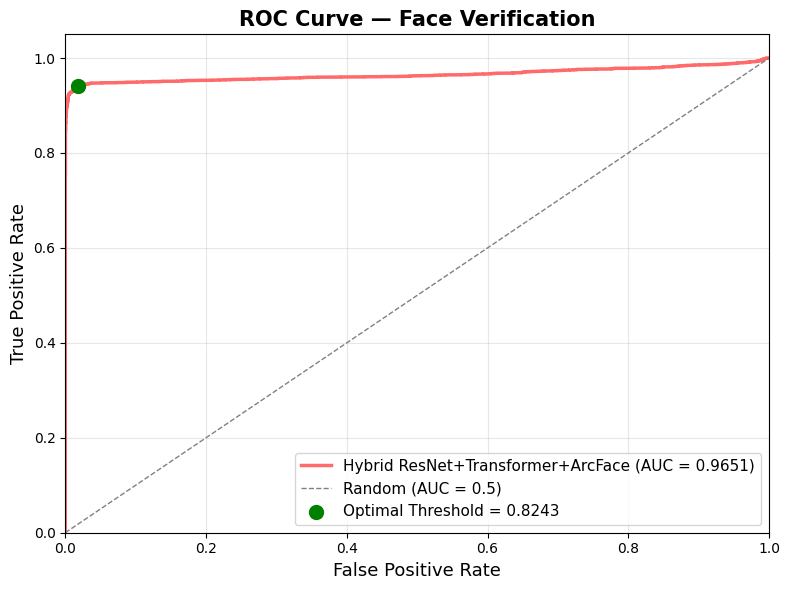

Saved: roc_curve.png


In [22]:
import glob, os, json, subprocess
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# ── Find best.pth ─────────────────────────────────────────────────────────────
list_of_dirs = glob.glob('logs/*')
if not list_of_dirs:
    raise FileNotFoundError('No logs/ folder found. Run training first.')

latest_dir        = max(list_of_dirs, key=os.path.getctime)
best_weights_path = os.path.join(latest_dir, 'best.pth')

if not os.path.exists(best_weights_path):
    raise FileNotFoundError(f'best.pth not found at {best_weights_path}')

print(f'Using weights: {best_weights_path}')

# Use Python variable for TEST_DATA (don't rely on $ENV in os.system)
TEST_DATA = os.environ.get('TEST_DATA', 'lensless_data/test/ymdct_npy')

# ── Face Recognition Test ─────────────────────────────────────────────────────
print('\n--- Face Recognition ---')
os.system(f'python test_face_recognition.py '
          f'--model transformer '
          f'--test_data "{TEST_DATA}" '
          f'--weights "{best_weights_path}" '
          f'--batch_size 32')

# ── Face Verification Test ────────────────────────────────────────────────────
print('\n--- Face Verification ---')
os.system(f'python test_face_verification.py '
          f'--model transformer '
          f'--test_data "{TEST_DATA}" '
          f'--pairs data/verification_pairs.txt '
          f'--weights "{best_weights_path}"')

# ── ROC Curve ─────────────────────────────────────────────────────────────────
if not os.path.exists('results.json'):
    print('ERROR: results.json not found. Verification test may have failed.')
else:
    with open('results.json', 'r') as f:
        results = json.load(f)

    fpr, tpr, thresholds = roc_curve(results['true_labels'], results['pred_scores'])
    roc_auc      = auc(fpr, tpr)
    optimal_idx  = (tpr - fpr).argmax()
    optimal_thresh = thresholds[optimal_idx]

    print(f'\nAUC              : {roc_auc:.4f}')
    print(f'Optimal Threshold: {optimal_thresh:.4f}  →  TPR: {tpr[optimal_idx]:.4f}, FPR: {fpr[optimal_idx]:.4f}')

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='#FF6B6B', lw=2.5,
             label=f'Hybrid ResNet+Transformer+ArcFace (AUC = {roc_auc:.4f})')
    plt.plot([0,1],[0,1], color='gray', lw=1, linestyle='--', label='Random (AUC = 0.5)')
    plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='green', s=100, zorder=5,
                label=f'Optimal Threshold = {optimal_thresh:.4f}')
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=13)
    plt.ylabel('True Positive Rate', fontsize=13)
    plt.title('ROC Curve — Face Verification', fontsize=15, fontweight='bold')
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig('roc_curve.png', dpi=150)
    plt.show()
    print('Saved: roc_curve.png')


Saved checkpoint: saved_models/exp_arcface_m04_s40_k2_ep120_batch64/best.pth
Saved checkpoint: saved_models/exp_arcface_m04_s40_k2_ep120_batch64/last.pth


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Model loaded.
Evaluating batch 79/79

Overall Accuracy : 94.57%
Top-5 Accuracy   : 99.56%
ROC AUC          : 0.9618
Optimal Threshold: 0.9805
Metrics saved.


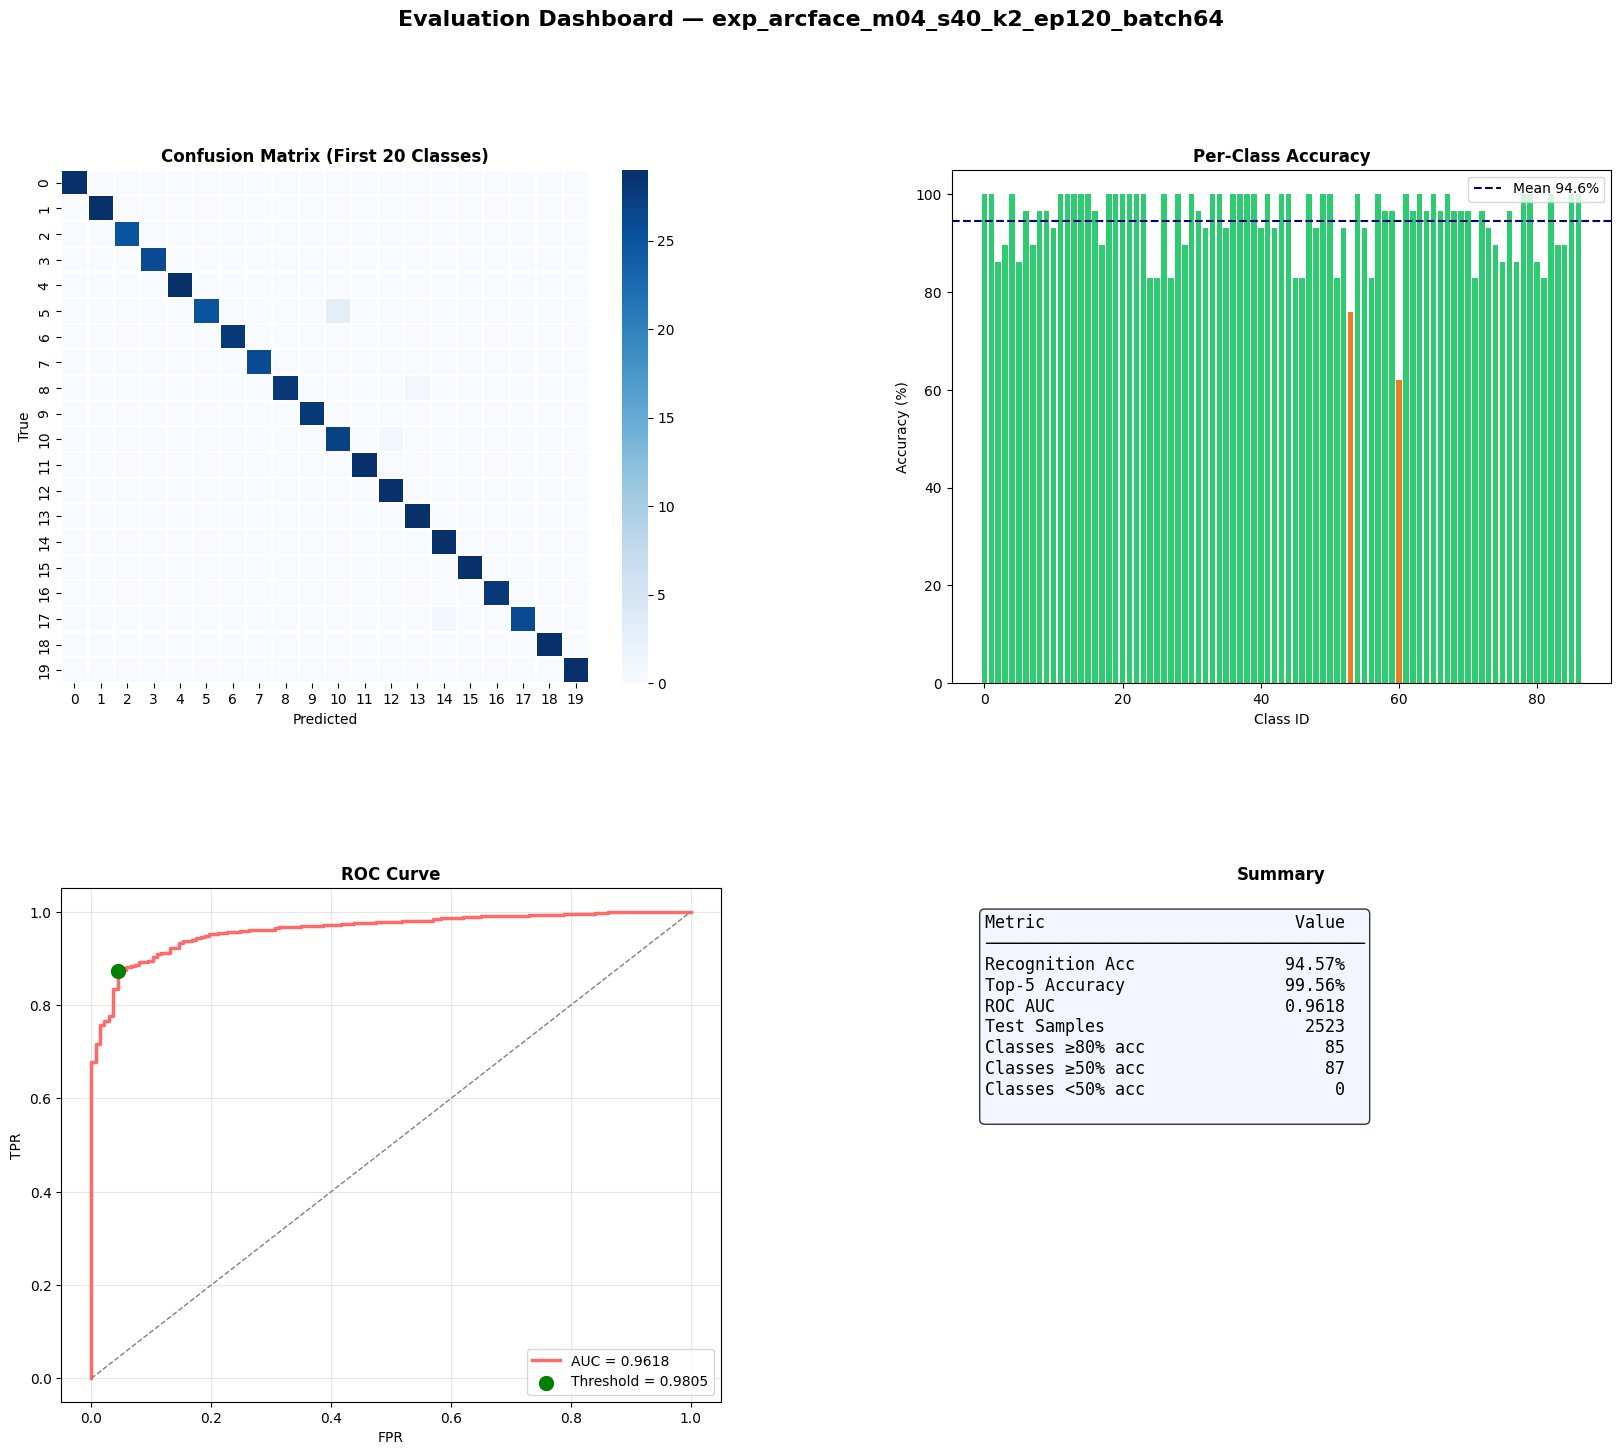

Dashboard saved: saved_models/exp_arcface_m04_s40_k2_ep120_batch64/dashboard.png

All saved to: saved_models/exp_arcface_m04_s40_k2_ep120_batch64/
Contents: ['best.pth', 'config.txt', 'metrics.json', 'dashboard.png', 'last.pth']


In [23]:
import os, shutil, glob, json
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from models.transformer_model import HybridResNetTransformer
from models.arcface import ArcMarginProduct
from my_data_class import Lensless_DCT_offline

# ── Config ────────────────────────────────────────────────────────────────────
SAVE_NAME  = 'exp_arcface_m04_s40_k3_ep120_batch128'   # <-- change per experiment
TEST_DATA  = os.environ.get('TEST_DATA', 'lensless_data/test/ymdct_npy')
ARCFACE_S  = 40.0   # match what you trained with
ARCFACE_M  = 0.4
ARCFACE_K  = 2

# ── 1. Find & copy checkpoint ─────────────────────────────────────────────────
list_of_dirs = glob.glob('logs/*')
latest_dir   = max(list_of_dirs, key=os.path.getctime)
SAVE_DIR     = os.path.join('saved_models', SAVE_NAME)
os.makedirs(SAVE_DIR, exist_ok=True)

for fname in ['best.pth', 'last.pth']:
    src = os.path.join(latest_dir, fname)
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(SAVE_DIR, fname))
        print(f'Saved checkpoint: {SAVE_DIR}/{fname}')

weights_path = os.path.join(SAVE_DIR, 'best.pth')

# ── 2. Load model ─────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
net = HybridResNetTransformer(in_channels=15, embed_dim=512, depth=4, num_heads=8, out_dim=768)
metric_fc = ArcMarginProduct(768, 87, s=ARCFACE_S, m=ARCFACE_M, K=ARCFACE_K)
ckpt = torch.load(weights_path, map_location=device)
net.load_state_dict(ckpt['net'])
metric_fc.load_state_dict(ckpt['metric_fc'])
net.to(device).eval()
metric_fc.to(device).eval()
print('Model loaded.')

# ── 3. Run inference ──────────────────────────────────────────────────────────
dataset = Lensless_DCT_offline(TEST_DATA)
loader  = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=False, num_workers=2)

all_preds, all_targets, all_probs = [], [], []
with torch.no_grad():
    for i, (data, targets) in enumerate(loader):
        x = torch.cat([d.to(device) for d in data], dim=1)
        features = net(x, tta=True)
        logits   = metric_fc(features)
        probs    = torch.softmax(logits, dim=1)
        all_preds.append(logits.argmax(1).cpu().numpy())
        all_targets.append(targets.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        print(f'\rEvaluating batch {i+1}/{len(loader)}', end='', flush=True)

all_preds   = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)
all_probs   = np.concatenate(all_probs)

# ── 4. Metrics ────────────────────────────────────────────────────────────────
acc  = (all_preds == all_targets).mean() * 100
top5 = np.mean([t in np.argsort(p)[-5:] for t, p in zip(all_targets, all_probs)]) * 100

# Verification AUC (use max class prob as score proxy)
conf_scores = all_probs.max(axis=1)
binary_correct = (all_preds == all_targets).astype(int)
fpr, tpr, thresholds = roc_curve(binary_correct, conf_scores)
roc_auc = auc(fpr, tpr)
optimal_idx    = (tpr - fpr).argmax()
optimal_thresh = thresholds[optimal_idx]

class_acc = [(all_preds[all_targets==c]==c).mean()*100
             if (all_targets==c).sum()>0 else 0 for c in range(87)]

print(f'\n\nOverall Accuracy : {acc:.2f}%')
print(f'Top-5 Accuracy   : {top5:.2f}%')
print(f'ROC AUC          : {roc_auc:.4f}')
print(f'Optimal Threshold: {optimal_thresh:.4f}')

# Save metrics JSON
metrics = {'recognition_acc': round(acc,4), 'top5_acc': round(top5,4),
           'roc_auc': round(roc_auc,4), 'optimal_threshold': round(float(optimal_thresh),4),
           'per_class_acc': class_acc}
with open(os.path.join(SAVE_DIR, 'metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=2)
print('Metrics saved.')

# ── 5. Dashboard Plot ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 16))
fig.suptitle(f'Evaluation Dashboard — {SAVE_NAME}', fontsize=16, fontweight='bold')
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# Confusion matrix (first 20 classes)
ax1 = fig.add_subplot(gs[0, 0])
mask = all_targets < 20
cm = confusion_matrix(all_targets[mask], all_preds[mask], labels=list(range(20)))
sns.heatmap(cm, ax=ax1, cmap='Blues', annot=False, linewidths=0.3, cbar=True)
ax1.set_title('Confusion Matrix (First 20 Classes)', fontweight='bold')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('True')

# Per-class accuracy bar
ax2 = fig.add_subplot(gs[0, 1])
colors = ['#2ecc71' if a>=80 else '#e67e22' if a>=50 else '#e74c3c' for a in class_acc]
ax2.bar(range(87), class_acc, color=colors, width=0.8)
ax2.axhline(acc, color='navy', linestyle='--', lw=1.5, label=f'Mean {acc:.1f}%')
ax2.set_title('Per-Class Accuracy', fontweight='bold')
ax2.set_xlabel('Class ID'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.set_ylim(0, 105)

# ROC Curve
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(fpr, tpr, color='#FF6B6B', lw=2.5, label=f'AUC = {roc_auc:.4f}')
ax3.plot([0,1],[0,1], color='gray', lw=1, linestyle='--')
ax3.scatter(fpr[optimal_idx], tpr[optimal_idx], color='green', s=100, zorder=5,
            label=f'Threshold = {optimal_thresh:.4f}')
ax3.set_title('ROC Curve', fontweight='bold')
ax3.set_xlabel('FPR'); ax3.set_ylabel('TPR')
ax3.legend(); ax3.grid(alpha=0.3)

# Summary
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')
summary = (f"{'Metric':<26}{'Value':>10}\n{'─'*38}\n"
           f"{'Recognition Acc':<26}{acc:>9.2f}%\n"
           f"{'Top-5 Accuracy':<26}{top5:>9.2f}%\n"
           f"{'ROC AUC':<26}{roc_auc:>10.4f}\n"
           f"{'Test Samples':<26}{len(all_targets):>10}\n"
           f"{'Classes ≥80% acc':<26}{sum(a>=80 for a in class_acc):>10}\n"
           f"{'Classes ≥50% acc':<26}{sum(a>=50 for a in class_acc):>10}\n"
           f"{'Classes <50% acc':<26}{sum(a<50  for a in class_acc):>10}\n")
ax4.text(0.05, 0.95, summary, transform=ax4.transAxes, fontsize=12,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#f0f4ff', alpha=0.8))
ax4.set_title('Summary', fontweight='bold')

# Save plot
plot_path = os.path.join(SAVE_DIR, 'dashboard.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Dashboard saved: {plot_path}')

# Save config
with open(os.path.join(SAVE_DIR, 'config.txt'), 'w') as f:
    f.write(f"Experiment : {SAVE_NAME}\n"
            f"Epochs     : 150  Batch: 512  Seed: 42\n"
            f"ArcFace    : m={ARCFACE_M}, s={ARCFACE_S}, K={ARCFACE_K}\n"
            f"Accuracy   : {acc:.2f}%  AUC: {roc_auc:.4f}\n")

print(f'\nAll saved to: {SAVE_DIR}/')
print('Contents:', os.listdir(SAVE_DIR))


In [ ]:
New

In [24]:
!python train.py \
    --model transformer \
    --train_data /content/lensless_data/train/ymdct_npy \
    --test_data  /content/lensless_data/test/ymdct_npy \
    --batch_size 128 \
    --num_epoch 120 \
    --seed 42 \
    --arcface_m 0.4 \
    --arcface_s 40 \
    --arcface_k 2 \
    --eta_min 1e-6

==> Using GPU(s): 1
==> Seed: 42
==> Preparing data..
==> Building model..
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
==> Ar

Using weights: logs/17-03-2026 12-18-41/best.pth

--- Face Recognition ---


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
Traceback (most recent call last):
  File "/content/Face-Verification-and-identif


--- Face Verification ---


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Accuracy = 5046/10092 = 0.5
AUC = 0.9729

AUC              : 0.9729
Optimal Threshold: 0.8340  →  TPR: 0.9209, FPR: 0.0139


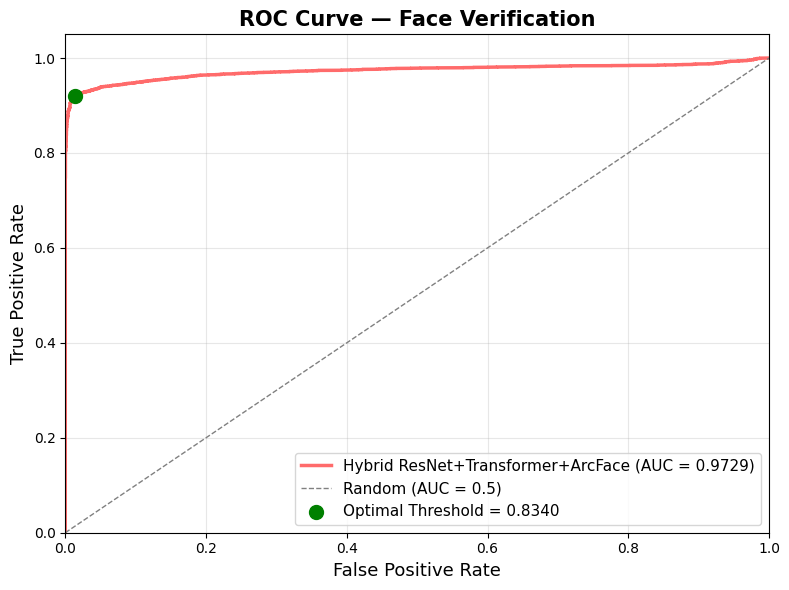

Saved: roc_curve.png


In [25]:
import glob, os, json, subprocess
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# ── Find best.pth ─────────────────────────────────────────────────────────────
list_of_dirs = glob.glob('logs/*')
if not list_of_dirs:
    raise FileNotFoundError('No logs/ folder found. Run training first.')

latest_dir        = max(list_of_dirs, key=os.path.getctime)
best_weights_path = os.path.join(latest_dir, 'best.pth')

if not os.path.exists(best_weights_path):
    raise FileNotFoundError(f'best.pth not found at {best_weights_path}')

print(f'Using weights: {best_weights_path}')

# Use Python variable for TEST_DATA (don't rely on $ENV in os.system)
TEST_DATA = os.environ.get('TEST_DATA', 'lensless_data/test/ymdct_npy')

# ── Face Recognition Test ─────────────────────────────────────────────────────
print('\n--- Face Recognition ---')
os.system(f'python test_face_recognition.py '
          f'--model transformer '
          f'--test_data "{TEST_DATA}" '
          f'--weights "{best_weights_path}" '
          f'--batch_size 32')

# ── Face Verification Test ────────────────────────────────────────────────────
print('\n--- Face Verification ---')
os.system(f'python test_face_verification.py '
          f'--model transformer '
          f'--test_data "{TEST_DATA}" '
          f'--pairs data/verification_pairs.txt '
          f'--weights "{best_weights_path}"')

# ── ROC Curve ─────────────────────────────────────────────────────────────────
if not os.path.exists('results.json'):
    print('ERROR: results.json not found. Verification test may have failed.')
else:
    with open('results.json', 'r') as f:
        results = json.load(f)

    fpr, tpr, thresholds = roc_curve(results['true_labels'], results['pred_scores'])
    roc_auc      = auc(fpr, tpr)
    optimal_idx  = (tpr - fpr).argmax()
    optimal_thresh = thresholds[optimal_idx]

    print(f'\nAUC              : {roc_auc:.4f}')
    print(f'Optimal Threshold: {optimal_thresh:.4f}  →  TPR: {tpr[optimal_idx]:.4f}, FPR: {fpr[optimal_idx]:.4f}')

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='#FF6B6B', lw=2.5,
             label=f'Hybrid ResNet+Transformer+ArcFace (AUC = {roc_auc:.4f})')
    plt.plot([0,1],[0,1], color='gray', lw=1, linestyle='--', label='Random (AUC = 0.5)')
    plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='green', s=100, zorder=5,
                label=f'Optimal Threshold = {optimal_thresh:.4f}')
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=13)
    plt.ylabel('True Positive Rate', fontsize=13)
    plt.title('ROC Curve — Face Verification', fontsize=15, fontweight='bold')
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig('roc_curve.png', dpi=150)
    plt.show()
    print('Saved: roc_curve.png')


Saved checkpoint: saved_models/exp_arcface_m04_s40_k3_ep120_batch128/best.pth
Saved checkpoint: saved_models/exp_arcface_m04_s40_k3_ep120_batch128/last.pth


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Model loaded.
Evaluating batch 79/79

Overall Accuracy : 94.21%
Top-5 Accuracy   : 99.37%
ROC AUC          : 0.9285
Optimal Threshold: 0.9572
Metrics saved.


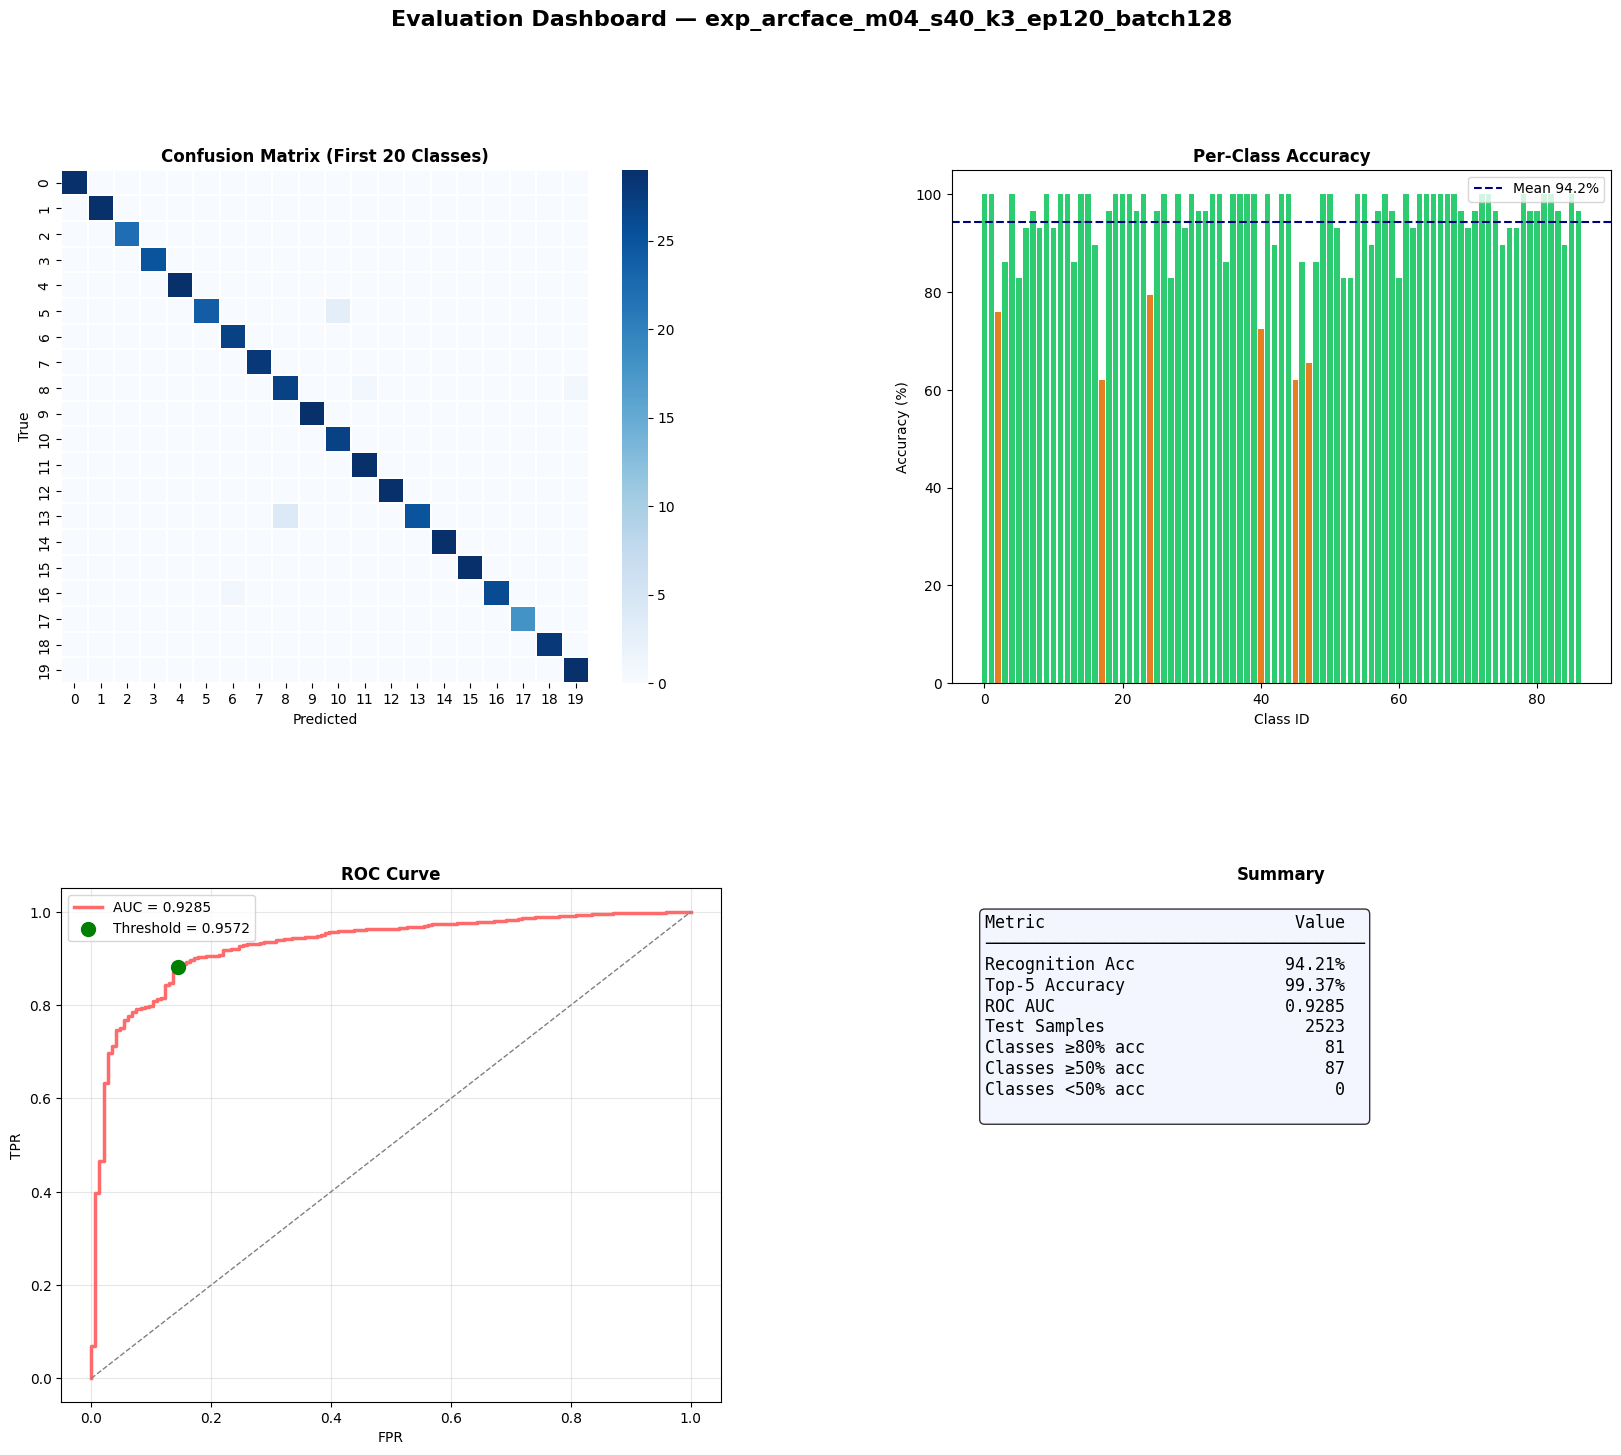

Dashboard saved: saved_models/exp_arcface_m04_s40_k3_ep120_batch128/dashboard.png

All saved to: saved_models/exp_arcface_m04_s40_k3_ep120_batch128/
Contents: ['best.pth', 'config.txt', 'metrics.json', 'dashboard.png', 'last.pth']


In [26]:
import os, shutil, glob, json
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from models.transformer_model import HybridResNetTransformer
from models.arcface import ArcMarginProduct
from my_data_class import Lensless_DCT_offline

# ── Config ────────────────────────────────────────────────────────────────────
SAVE_NAME  = 'exp_arcface_m04_s40_k3_ep120_batch128'   # <-- change per experiment
TEST_DATA  = os.environ.get('TEST_DATA', 'lensless_data/test/ymdct_npy')
ARCFACE_S  = 40.0   # match what you trained with
ARCFACE_M  = 0.4
ARCFACE_K  = 2

# ── 1. Find & copy checkpoint ─────────────────────────────────────────────────
list_of_dirs = glob.glob('logs/*')
latest_dir   = max(list_of_dirs, key=os.path.getctime)
SAVE_DIR     = os.path.join('saved_models', SAVE_NAME)
os.makedirs(SAVE_DIR, exist_ok=True)

for fname in ['best.pth', 'last.pth']:
    src = os.path.join(latest_dir, fname)
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(SAVE_DIR, fname))
        print(f'Saved checkpoint: {SAVE_DIR}/{fname}')

weights_path = os.path.join(SAVE_DIR, 'best.pth')

# ── 2. Load model ─────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
net = HybridResNetTransformer(in_channels=15, embed_dim=512, depth=4, num_heads=8, out_dim=768)
metric_fc = ArcMarginProduct(768, 87, s=ARCFACE_S, m=ARCFACE_M, K=ARCFACE_K)
ckpt = torch.load(weights_path, map_location=device)
net.load_state_dict(ckpt['net'])
metric_fc.load_state_dict(ckpt['metric_fc'])
net.to(device).eval()
metric_fc.to(device).eval()
print('Model loaded.')

# ── 3. Run inference ──────────────────────────────────────────────────────────
dataset = Lensless_DCT_offline(TEST_DATA)
loader  = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=False, num_workers=2)

all_preds, all_targets, all_probs = [], [], []
with torch.no_grad():
    for i, (data, targets) in enumerate(loader):
        x = torch.cat([d.to(device) for d in data], dim=1)
        features = net(x, tta=True)
        logits   = metric_fc(features)
        probs    = torch.softmax(logits, dim=1)
        all_preds.append(logits.argmax(1).cpu().numpy())
        all_targets.append(targets.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        print(f'\rEvaluating batch {i+1}/{len(loader)}', end='', flush=True)

all_preds   = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)
all_probs   = np.concatenate(all_probs)

# ── 4. Metrics ────────────────────────────────────────────────────────────────
acc  = (all_preds == all_targets).mean() * 100
top5 = np.mean([t in np.argsort(p)[-5:] for t, p in zip(all_targets, all_probs)]) * 100

# Verification AUC (use max class prob as score proxy)
conf_scores = all_probs.max(axis=1)
binary_correct = (all_preds == all_targets).astype(int)
fpr, tpr, thresholds = roc_curve(binary_correct, conf_scores)
roc_auc = auc(fpr, tpr)
optimal_idx    = (tpr - fpr).argmax()
optimal_thresh = thresholds[optimal_idx]

class_acc = [(all_preds[all_targets==c]==c).mean()*100
             if (all_targets==c).sum()>0 else 0 for c in range(87)]

print(f'\n\nOverall Accuracy : {acc:.2f}%')
print(f'Top-5 Accuracy   : {top5:.2f}%')
print(f'ROC AUC          : {roc_auc:.4f}')
print(f'Optimal Threshold: {optimal_thresh:.4f}')

# Save metrics JSON
metrics = {'recognition_acc': round(acc,4), 'top5_acc': round(top5,4),
           'roc_auc': round(roc_auc,4), 'optimal_threshold': round(float(optimal_thresh),4),
           'per_class_acc': class_acc}
with open(os.path.join(SAVE_DIR, 'metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=2)
print('Metrics saved.')

# ── 5. Dashboard Plot ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 16))
fig.suptitle(f'Evaluation Dashboard — {SAVE_NAME}', fontsize=16, fontweight='bold')
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# Confusion matrix (first 20 classes)
ax1 = fig.add_subplot(gs[0, 0])
mask = all_targets < 20
cm = confusion_matrix(all_targets[mask], all_preds[mask], labels=list(range(20)))
sns.heatmap(cm, ax=ax1, cmap='Blues', annot=False, linewidths=0.3, cbar=True)
ax1.set_title('Confusion Matrix (First 20 Classes)', fontweight='bold')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('True')

# Per-class accuracy bar
ax2 = fig.add_subplot(gs[0, 1])
colors = ['#2ecc71' if a>=80 else '#e67e22' if a>=50 else '#e74c3c' for a in class_acc]
ax2.bar(range(87), class_acc, color=colors, width=0.8)
ax2.axhline(acc, color='navy', linestyle='--', lw=1.5, label=f'Mean {acc:.1f}%')
ax2.set_title('Per-Class Accuracy', fontweight='bold')
ax2.set_xlabel('Class ID'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.set_ylim(0, 105)

# ROC Curve
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(fpr, tpr, color='#FF6B6B', lw=2.5, label=f'AUC = {roc_auc:.4f}')
ax3.plot([0,1],[0,1], color='gray', lw=1, linestyle='--')
ax3.scatter(fpr[optimal_idx], tpr[optimal_idx], color='green', s=100, zorder=5,
            label=f'Threshold = {optimal_thresh:.4f}')
ax3.set_title('ROC Curve', fontweight='bold')
ax3.set_xlabel('FPR'); ax3.set_ylabel('TPR')
ax3.legend(); ax3.grid(alpha=0.3)

# Summary
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')
summary = (f"{'Metric':<26}{'Value':>10}\n{'─'*38}\n"
           f"{'Recognition Acc':<26}{acc:>9.2f}%\n"
           f"{'Top-5 Accuracy':<26}{top5:>9.2f}%\n"
           f"{'ROC AUC':<26}{roc_auc:>10.4f}\n"
           f"{'Test Samples':<26}{len(all_targets):>10}\n"
           f"{'Classes ≥80% acc':<26}{sum(a>=80 for a in class_acc):>10}\n"
           f"{'Classes ≥50% acc':<26}{sum(a>=50 for a in class_acc):>10}\n"
           f"{'Classes <50% acc':<26}{sum(a<50  for a in class_acc):>10}\n")
ax4.text(0.05, 0.95, summary, transform=ax4.transAxes, fontsize=12,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#f0f4ff', alpha=0.8))
ax4.set_title('Summary', fontweight='bold')

# Save plot
plot_path = os.path.join(SAVE_DIR, 'dashboard.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Dashboard saved: {plot_path}')

# Save config
with open(os.path.join(SAVE_DIR, 'config.txt'), 'w') as f:
    f.write(f"Experiment : {SAVE_NAME}\n"
            f"Epochs     : 150  Batch: 512  Seed: 42\n"
            f"ArcFace    : m={ARCFACE_M}, s={ARCFACE_S}, K={ARCFACE_K}\n"
            f"Accuracy   : {acc:.2f}%  AUC: {roc_auc:.4f}\n")

print(f'\nAll saved to: {SAVE_DIR}/')
print('Contents:', os.listdir(SAVE_DIR))


In [ ]:
New

In [27]:
SAVE_NAME = 'exp_v2_baseline_s42'
!python train.py \
    --model transformer \
    --train_data $TRAIN_DATA \
    --test_data  $TEST_DATA \
    --batch_size 128 --num_epoch 115 \
    --seed 42 --eta_min 1e-6


==> Using GPU(s): 1
==> Seed: 42
==> Preparing data..
==> Building model..
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
==> Ar

Using weights: logs/17-03-2026 12-55-52/best.pth

--- Face Recognition ---


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Processed epoch 1 / 79
Processed epoch 2 / 79
Processed epoch 3 / 79
Processed epoch 4 / 79
Processed epoch 5 / 79
Processed epoch 6 / 79
Processed epoch 7 / 79
Processed epoch 8 / 79
Processed epoch 9 / 79
Processed epoch 10 / 79
Processed epoch 11 / 79
Processed epoch 12 / 79
Processed epoch 13 / 79
Processed epoch 14 / 79
Processed epoch 15 / 79
Processed epoch 16 / 79
Processed epoch 17 / 79
Processed epoch 18 / 79
Processed epoch 19 / 79
Processed epoch 20 / 79
Processed epoch 21 / 79
Processed epoch 22 / 79
Processed epoch 23 / 79
Processed epoch 24 / 79
Processed epoch 25 / 79
Processed epoch 26 / 79
Processed epoch 27 / 79
Processed epoch 28 / 79
Processed epoch 29 / 79
Processed epoch 30 / 79
Processed epoch 31 / 79
Processed epoch 32 / 79
Processed epoch 33 / 79
Processed epoch 34 / 79
Processed epoch 35 / 79
Processed epoch 36 / 79
Processed epoch 37 / 79
Processed epoch 38 / 79
Processed epoch 39 / 79
Processed epoch 40 / 79
Processed epoch 41 / 79
Processed epoch 42 / 79
P

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Accuracy = 5046/10092 = 0.5
AUC = 0.9974

AUC              : 0.9974
Optimal Threshold: 0.9525  →  TPR: 0.9790, FPR: 0.0139


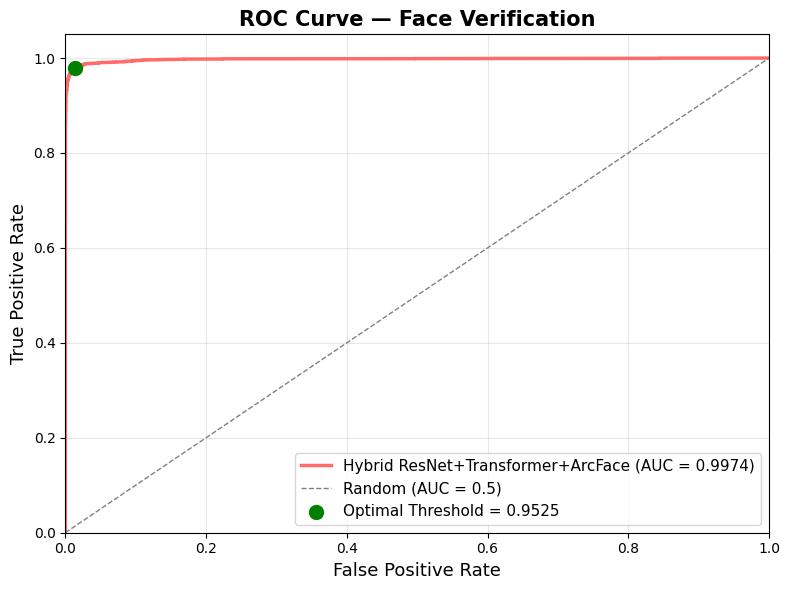

Saved: roc_curve.png


In [28]:
import glob, os, json, subprocess
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# ── Find best.pth ─────────────────────────────────────────────────────────────
list_of_dirs = glob.glob('logs/*')
if not list_of_dirs:
    raise FileNotFoundError('No logs/ folder found. Run training first.')

latest_dir        = max(list_of_dirs, key=os.path.getctime)
best_weights_path = os.path.join(latest_dir, 'best.pth')

if not os.path.exists(best_weights_path):
    raise FileNotFoundError(f'best.pth not found at {best_weights_path}')

print(f'Using weights: {best_weights_path}')

# Use Python variable for TEST_DATA (don't rely on $ENV in os.system)
TEST_DATA = os.environ.get('TEST_DATA', 'lensless_data/test/ymdct_npy')

# ── Face Recognition Test ─────────────────────────────────────────────────────
print('\n--- Face Recognition ---')
os.system(f'python test_face_recognition.py '
          f'--model transformer '
          f'--test_data "{TEST_DATA}" '
          f'--weights "{best_weights_path}" '
          f'--batch_size 32')

# ── Face Verification Test ────────────────────────────────────────────────────
print('\n--- Face Verification ---')
os.system(f'python test_face_verification.py '
          f'--model transformer '
          f'--test_data "{TEST_DATA}" '
          f'--pairs data/verification_pairs.txt '
          f'--weights "{best_weights_path}"')

# ── ROC Curve ─────────────────────────────────────────────────────────────────
if not os.path.exists('results.json'):
    print('ERROR: results.json not found. Verification test may have failed.')
else:
    with open('results.json', 'r') as f:
        results = json.load(f)

    fpr, tpr, thresholds = roc_curve(results['true_labels'], results['pred_scores'])
    roc_auc      = auc(fpr, tpr)
    optimal_idx  = (tpr - fpr).argmax()
    optimal_thresh = thresholds[optimal_idx]

    print(f'\nAUC              : {roc_auc:.4f}')
    print(f'Optimal Threshold: {optimal_thresh:.4f}  →  TPR: {tpr[optimal_idx]:.4f}, FPR: {fpr[optimal_idx]:.4f}')

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='#FF6B6B', lw=2.5,
             label=f'Hybrid ResNet+Transformer+ArcFace (AUC = {roc_auc:.4f})')
    plt.plot([0,1],[0,1], color='gray', lw=1, linestyle='--', label='Random (AUC = 0.5)')
    plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='green', s=100, zorder=5,
                label=f'Optimal Threshold = {optimal_thresh:.4f}')
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=13)
    plt.ylabel('True Positive Rate', fontsize=13)
    plt.title('ROC Curve — Face Verification', fontsize=15, fontweight='bold')
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig('roc_curve.png', dpi=150)
    plt.show()
    print('Saved: roc_curve.png')


Saved checkpoint: saved_models/exp_v2_baseline_s42/best.pth
Saved checkpoint: saved_models/exp_v2_baseline_s42/last.pth


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Model loaded.
Evaluating batch 79/79

Overall Accuracy : 94.33%
Top-5 Accuracy   : 99.25%
ROC AUC          : 0.9204
Optimal Threshold: 0.3297
Metrics saved.


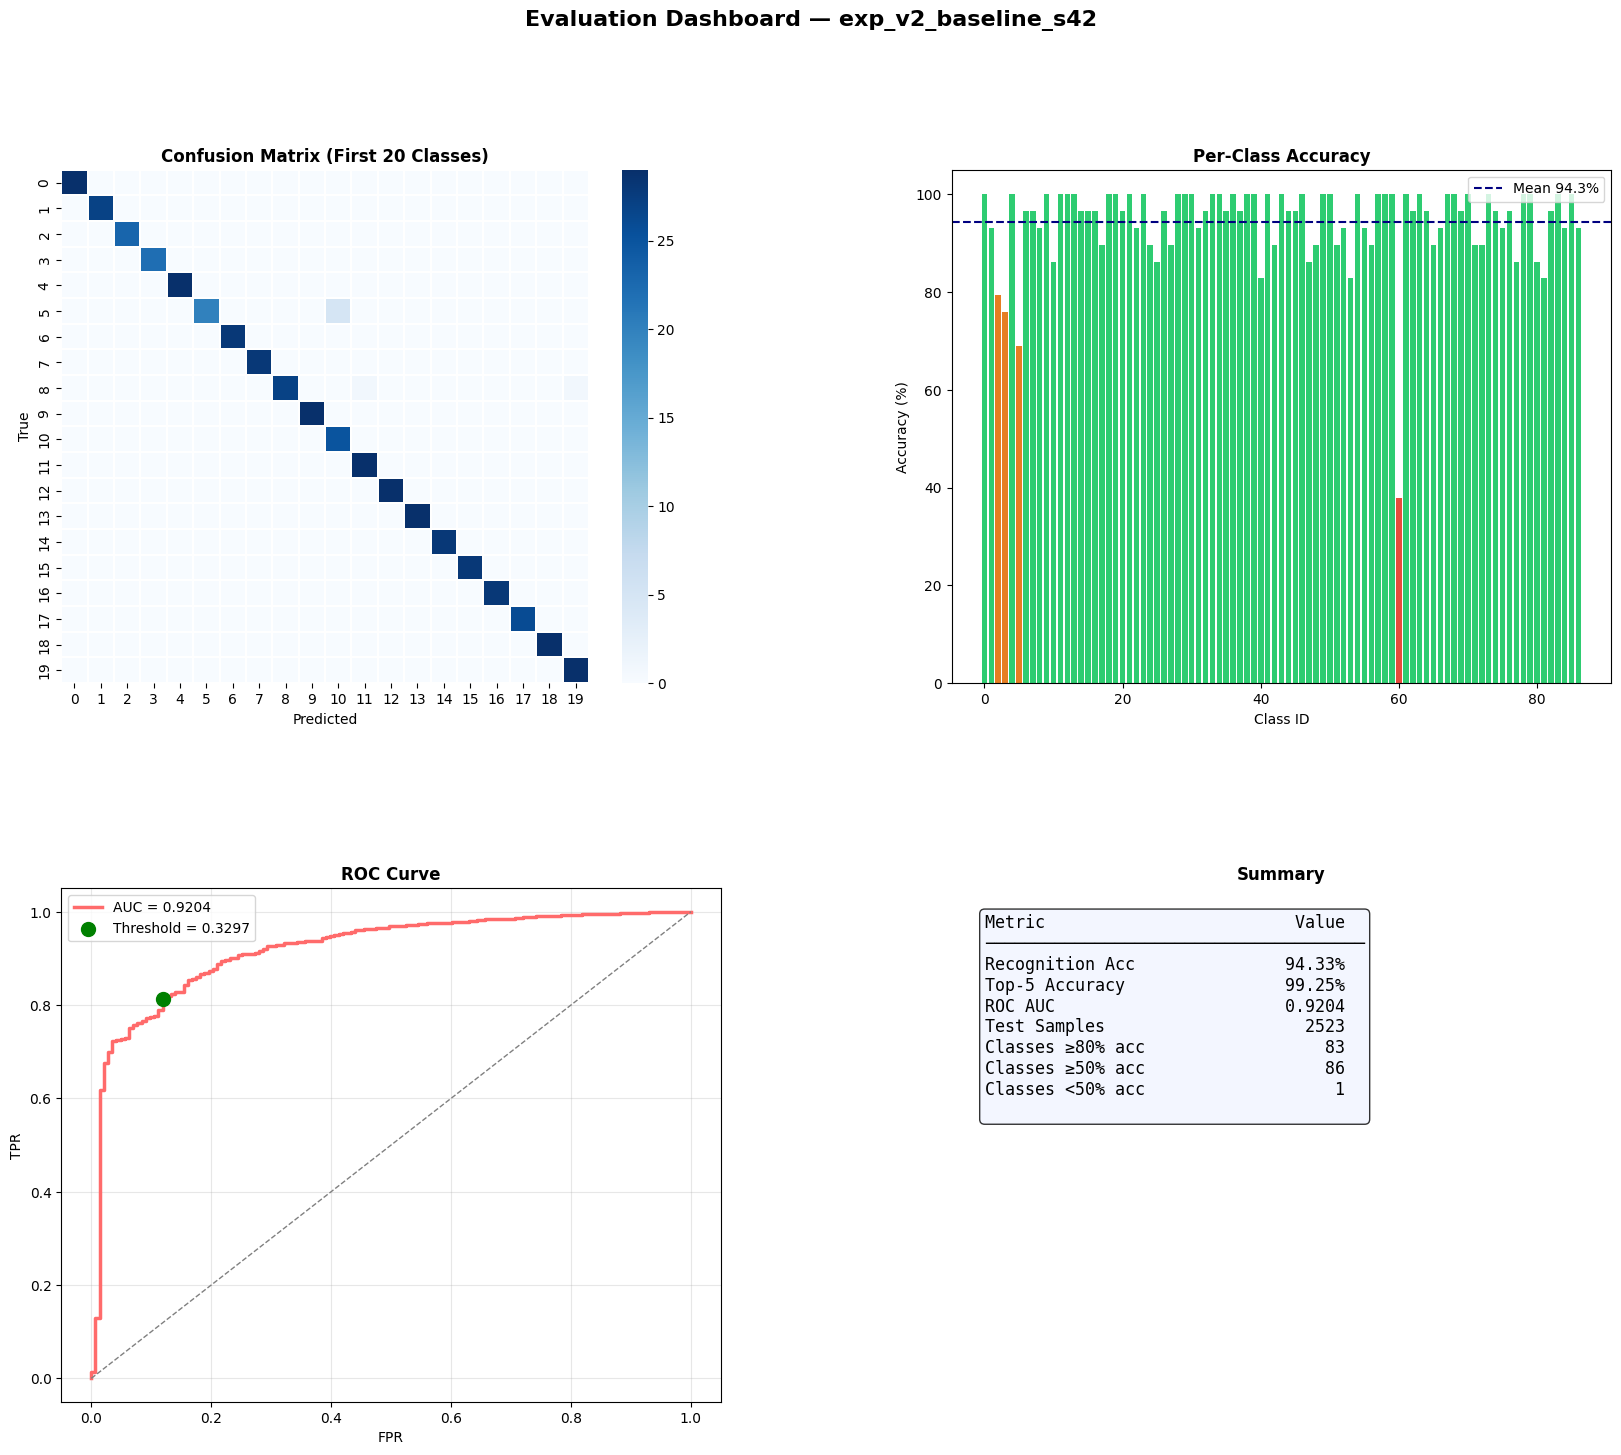

Dashboard saved: saved_models/exp_v2_baseline_s42/dashboard.png

All saved to: saved_models/exp_v2_baseline_s42/
Contents: ['best.pth', 'config.txt', 'metrics.json', 'dashboard.png', 'last.pth']


In [29]:
import os, shutil, glob, json
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from models.transformer_model import HybridResNetTransformer
from models.arcface import ArcMarginProduct
from my_data_class import Lensless_DCT_offline

# ── Config ────────────────────────────────────────────────────────────────────
SAVE_NAME  = 'exp_v2_baseline_s42'              # ✅ corrected
TEST_DATA  = os.environ.get('TEST_DATA', 'lensless_data/test/ymdct_npy')
ARCFACE_S  = 64.0   # ✅ v2 baseline uses default s=64
ARCFACE_M  = 0.5    # ✅ v2 baseline uses default m=0.5
ARCFACE_K  = 3      # ✅ v2 baseline uses K=3

# ── 1. Find & copy checkpoint ─────────────────────────────────────────────────
list_of_dirs = glob.glob('logs/*')
latest_dir   = max(list_of_dirs, key=os.path.getctime)
SAVE_DIR     = os.path.join('saved_models', SAVE_NAME)
os.makedirs(SAVE_DIR, exist_ok=True)

for fname in ['best.pth', 'last.pth']:
    src = os.path.join(latest_dir, fname)
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(SAVE_DIR, fname))
        print(f'Saved checkpoint: {SAVE_DIR}/{fname}')

weights_path = os.path.join(SAVE_DIR, 'best.pth')

# ── 2. Load model ─────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
net = HybridResNetTransformer(in_channels=15, embed_dim=512, depth=4, num_heads=8, out_dim=768)
metric_fc = ArcMarginProduct(768, 87, s=ARCFACE_S, m=ARCFACE_M, K=ARCFACE_K)
ckpt = torch.load(weights_path, map_location=device)
net.load_state_dict(ckpt['net'])
metric_fc.load_state_dict(ckpt['metric_fc'])
net.to(device).eval()
metric_fc.to(device).eval()
print('Model loaded.')

# ── 3. Run inference ──────────────────────────────────────────────────────────
dataset = Lensless_DCT_offline(TEST_DATA)
loader  = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=False, num_workers=2)

all_preds, all_targets, all_probs = [], [], []
with torch.no_grad():
    for i, (data, targets) in enumerate(loader):
        x = torch.cat([d.to(device) for d in data], dim=1)
        features = net(x, tta=True)
        logits   = metric_fc(features)
        probs    = torch.softmax(logits, dim=1)
        all_preds.append(logits.argmax(1).cpu().numpy())
        all_targets.append(targets.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        print(f'\rEvaluating batch {i+1}/{len(loader)}', end='', flush=True)

all_preds   = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)
all_probs   = np.concatenate(all_probs)

# ── 4. Metrics ────────────────────────────────────────────────────────────────
acc  = (all_preds == all_targets).mean() * 100
top5 = np.mean([t in np.argsort(p)[-5:] for t, p in zip(all_targets, all_probs)]) * 100

conf_scores    = all_probs.max(axis=1)
binary_correct = (all_preds == all_targets).astype(int)
fpr, tpr, thresholds = roc_curve(binary_correct, conf_scores)
roc_auc        = auc(fpr, tpr)
optimal_idx    = (tpr - fpr).argmax()
optimal_thresh = thresholds[optimal_idx]

class_acc = [(all_preds[all_targets==c]==c).mean()*100
             if (all_targets==c).sum()>0 else 0 for c in range(87)]

print(f'\n\nOverall Accuracy : {acc:.2f}%')
print(f'Top-5 Accuracy   : {top5:.2f}%')
print(f'ROC AUC          : {roc_auc:.4f}')
print(f'Optimal Threshold: {optimal_thresh:.4f}')

metrics = {'recognition_acc': round(acc,4), 'top5_acc': round(top5,4),
           'roc_auc': round(roc_auc,4), 'optimal_threshold': round(float(optimal_thresh),4),
           'per_class_acc': class_acc}
with open(os.path.join(SAVE_DIR, 'metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=2)
print('Metrics saved.')

# ── 5. Dashboard Plot ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 16))
fig.suptitle(f'Evaluation Dashboard — {SAVE_NAME}', fontsize=16, fontweight='bold')
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
mask = all_targets < 20
cm = confusion_matrix(all_targets[mask], all_preds[mask], labels=list(range(20)))
sns.heatmap(cm, ax=ax1, cmap='Blues', annot=False, linewidths=0.3, cbar=True)
ax1.set_title('Confusion Matrix (First 20 Classes)', fontweight='bold')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('True')

ax2 = fig.add_subplot(gs[0, 1])
colors = ['#2ecc71' if a>=80 else '#e67e22' if a>=50 else '#e74c3c' for a in class_acc]
ax2.bar(range(87), class_acc, color=colors, width=0.8)
ax2.axhline(acc, color='navy', linestyle='--', lw=1.5, label=f'Mean {acc:.1f}%')
ax2.set_title('Per-Class Accuracy', fontweight='bold')
ax2.set_xlabel('Class ID'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.set_ylim(0, 105)

ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(fpr, tpr, color='#FF6B6B', lw=2.5, label=f'AUC = {roc_auc:.4f}')
ax3.plot([0,1],[0,1], color='gray', lw=1, linestyle='--')
ax3.scatter(fpr[optimal_idx], tpr[optimal_idx], color='green', s=100, zorder=5,
            label=f'Threshold = {optimal_thresh:.4f}')
ax3.set_title('ROC Curve', fontweight='bold')
ax3.set_xlabel('FPR'); ax3.set_ylabel('TPR')
ax3.legend(); ax3.grid(alpha=0.3)

ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')
summary = (f"{'Metric':<26}{'Value':>10}\n{'─'*38}\n"
           f"{'Recognition Acc':<26}{acc:>9.2f}%\n"
           f"{'Top-5 Accuracy':<26}{top5:>9.2f}%\n"
           f"{'ROC AUC':<26}{roc_auc:>10.4f}\n"
           f"{'Test Samples':<26}{len(all_targets):>10}\n"
           f"{'Classes ≥80% acc':<26}{sum(a>=80 for a in class_acc):>10}\n"
           f"{'Classes ≥50% acc':<26}{sum(a>=50 for a in class_acc):>10}\n"
           f"{'Classes <50% acc':<26}{sum(a<50  for a in class_acc):>10}\n")
ax4.text(0.05, 0.95, summary, transform=ax4.transAxes, fontsize=12,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#f0f4ff', alpha=0.8))
ax4.set_title('Summary', fontweight='bold')

plot_path = os.path.join(SAVE_DIR, 'dashboard.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Dashboard saved: {plot_path}')

with open(os.path.join(SAVE_DIR, 'config.txt'), 'w') as f:
    f.write(f"Experiment : {SAVE_NAME}\n"
            f"Epochs     : 115  Batch: 128  Seed: 42\n"   # ✅ corrected
            f"ArcFace    : m={ARCFACE_M}, s={ARCFACE_S}, K={ARCFACE_K}\n"
            f"Accuracy   : {acc:.2f}%  AUC: {roc_auc:.4f}\n")

print(f'\nAll saved to: {SAVE_DIR}/')
print('Contents:', os.listdir(SAVE_DIR))


In [ ]:
import os, shutil
from IPython.display import FileLink, display

REPO_DIR = '/content/Face-Verification-and-identification-using-Lens-less-camera-and-transformer-model'

# Create zip of saved_models
zip_output = os.path.join(REPO_DIR, 'saved_models_all')
shutil.make_archive(zip_output, 'zip',
                    root_dir=REPO_DIR,
                    base_dir='saved_models')

zip_file = zip_output + '.zip'
size_mb = round(os.path.getsize(zip_file) / (1024**2), 1)
print(f'Created: {zip_file}  ({size_mb} MB)')

# Show clickable download link
display(FileLink(os.path.relpath(zip_file, REPO_DIR), result_html_prefix='📥 Download: '))
